# Análisis de Estrategias - Deep Learning
## Comparación: Transfer Learning vs CNN From Scratch

En este notebook se comparan dos estrategias diferentes para resolver el problema de clasificación de imágenes en CIFAR-100:
1. **Transfer Learning**: Utilizar una red preentrenada en ImageNet
2. **CNN from Scratch**: Entrenar una red desde cero sin pesos preentrenados

**Grupo:** [Nombre del Grupo]

**Integrantes:**
- Alejandro Malagon
- Marta Dominguez
- Yessenia Padilla
- Ismael Santamarta

---
# 1. IMPORTS Y CONFIGURACIÓN

Importamos todas las librerías necesarias para el análisis.
- **TensorFlow/Keras**: Para construir y entrenar modelos
- **NumPy/Matplotlib**: Para procesamiento de datos y visualización
- **sklearn**: Para calcular métricas de evaluación

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow version: {tf.__version__}')
print('[INFO] Librerías cargadas correctamente')

/Users/alex/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow version: 2.13.1
[INFO] Librerías cargadas correctamente


In [4]:
# ###################### CONFIGURACIÓN GPU MAC M4 ######################
import tensorflow as tf
import time

print("="*70)
print(" CONFIGURACIÓN DE GPU PARA MAC M4")
print("="*70)

# Versión TensorFlow
print(f"\n✓ TensorFlow: {tf.__version__}")

# Detectar dispositivos
devices = tf.config.list_physical_devices()
gpus = tf.config.list_physical_devices('GPU')
cpus = tf.config.list_physical_devices('CPU')

print(f"\n Dispositivos detectados:")
print(f"  • CPU: {len(cpus)}")
print(f"  • GPU: {len(gpus)}")

for device in devices:
    print(f"    - {device}")

# Configurar GPU
if gpus:
    print(f"\n GPU DETECTADA - Metal GPU está disponible")
    try:
        # Permitir crecimiento dinámico de memoria
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✓ Crecimiento dinámico de memoria: ON")
        
        # Mixed precision para mejor rendimiento
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print("✓ Mixed precision (float16): ON")
        
        # Test de GPU
        with tf.device('/GPU:0'):
            test = tf.matmul(tf.ones((1000, 1000)), tf.ones((1000, 1000)))
        print("✓ GPU funcionando correctamente")
        print("✓ El entrenamiento usará GPU - ¡Será mucho más rápido!")
        
    except RuntimeError as e:
        print(f"  Error al configurar GPU: {e}")
        print(" Usando CPU en su lugar")
else:
    print("\n  GPU NO detectada")
    print("Instala tensorflow-metal con: pip3 install tensorflow-metal")
    print(" Usando CPU en su lugar")

print("\n" + "="*70 + "\n")
# ###################### FIN CONFIGURACIÓN GPU ######################

 CONFIGURACIÓN DE GPU PARA MAC M4

✓ TensorFlow: 2.13.1

 Dispositivos detectados:
  • CPU: 1
  • GPU: 1
    - PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
    - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

 GPU DETECTADA - Metal GPU está disponible
✓ Crecimiento dinámico de memoria: ON
Your GPU may run slowly with dtype policy mixed_float16 because it does not have compute capability of at least 7.0. Your GPU:
  METAL, no compute capability (probably not an Nvidia GPU)
See https://developer.nvidia.com/cuda-gpus for a list of GPUs and their compute capabilities.
If you will use compatible GPU(s) not attached to this host, e.g. by running a multi-worker model, you can ignore this warning. This message will only be logged once
✓ Mixed precision (float16): ON


2025-11-10 21:05:23.902772: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-11-10 21:05:23.902806: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-11-10 21:05:23.902815: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-11-10 21:05:23.902942: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-10 21:05:23.903118: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


✓ GPU funcionando correctamente
✓ El entrenamiento usará GPU - ¡Será mucho más rápido!




---
# 2. CARGA Y PREPARACIÓN DE DATOS

## 2.1 Carga del Dataset CIFAR-100
CIFAR-100 es un dataset de 60,000 imágenes en color (32x32 píxeles) con 100 clases diferentes.
- **Conjunto de entrenamiento**: 50,000 imágenes
- **Conjunto de test**: 10,000 imágenes
- **Clases**: 100 (apple, aquarium_fish, baby, bear, etc.)

## 2.2 Preprocesamiento
Se realiza normalización de los datos (valores entre 0 y 1) y codificación one-hot de las etiquetas.

In [5]:
# Cargar CIFAR-100
print('='*60)
print('CARGA DE DATOS')
print('='*60)
print('[INFO] Cargando dataset CIFAR-100...')
((x_train, y_train), (x_test, y_test)) = cifar100.load_data()

print(f'Conjunto de entrenamiento: {x_train.shape}')
print(f'Conjunto de test: {x_test.shape}')
print(f'Rango de valores píxeles: [{x_train.min()}, {x_train.max()}]')

CARGA DE DATOS
[INFO] Cargando dataset CIFAR-100...
Conjunto de entrenamiento: (50000, 32, 32, 3)
Conjunto de test: (10000, 32, 32, 3)
Rango de valores píxeles: [0, 255]


In [37]:
# Normalizar: valores entre 0 y 1
print('\n[INFO] Normalizando datos...')
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
print(f'Nuevo rango: [{x_train.min()}, {x_train.max()}]')

# One-hot encoding
print('\n[INFO] Codificando etiquetas a one-hot...')
y_train_cat = keras.utils.to_categorical(y_train, 100)
y_test_cat = keras.utils.to_categorical(y_test, 100)
print(f'Dimensión de etiquetas: {y_train_cat.shape}')
print('[INFO] Datos preprocesados correctamente')


[INFO] Normalizando datos...
Nuevo rango: [0.0, 1.0]

[INFO] Codificando etiquetas a one-hot...
Dimensión de etiquetas: (50000, 100)
[INFO] Datos preprocesados correctamente



[INFO] Visualizando muestras del dataset...


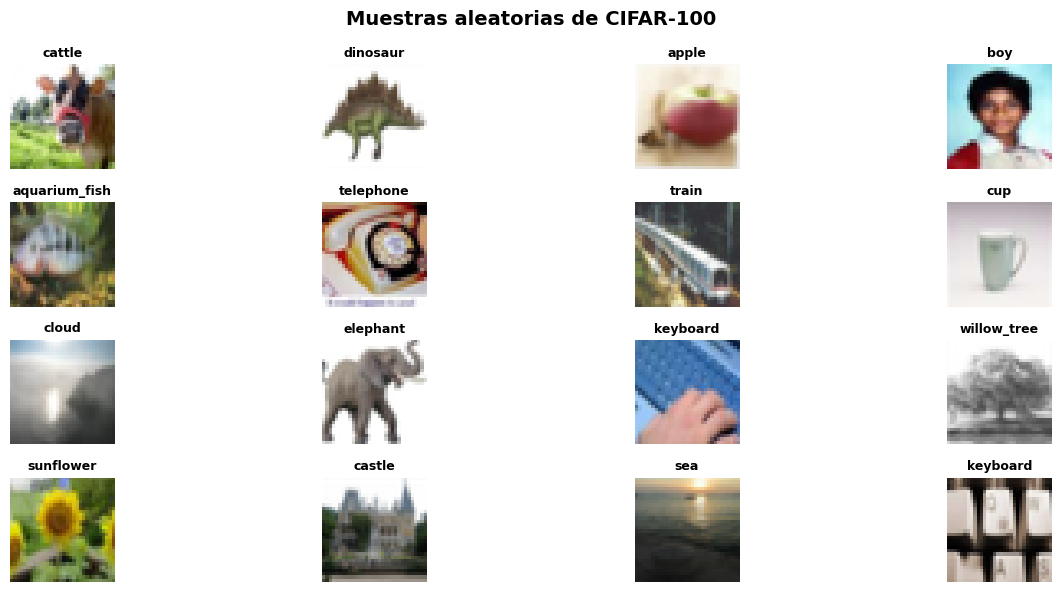

[INFO] Visualización completada


In [38]:
# Nombres de las 100 clases
labelNames = ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm']

print('\n[INFO] Visualizando muestras del dataset...')
plt.figure(figsize=(14, 6))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(x_train[i])
    label_idx = y_train[i][0]
    plt.title(labelNames[label_idx], fontsize=9, fontweight='bold')
    plt.axis('off')
plt.suptitle('Muestras aleatorias de CIFAR-100', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('[INFO] Visualización completada')

---
# 3. DATA AUGMENTATION

## Técnica: Data Augmentation

Data Augmentation es una técnica para generar nuevas muestras de entrenamiento mediante transformaciones aleatorias aplicadas a las imágenes originales. Esto ayuda a:
- **Aumentar la cantidad efectiva de datos**: La red ve variaciones de las mismas imágenes
- **Mejorar la generalización**: El modelo aprende características más robustas
- **Reducir overfitting**: Evita que la red memorice las imágenes exactas

## Transformaciones aplicadas:
- **Rotación**: Hasta 15 grados
- **Desplazamiento**: Hasta 15% horizontal y vertical
- **Zoom**: Hasta 10%
- **Flip horizontal**: Reflejo izquierda-derecha

In [6]:
print('='*60)
print('DATA AUGMENTATION')
print('='*60)
print('\n[INFO] Configurando transformaciones de Data Augmentation...')

datagen = ImageDataGenerator(
    rotation_range=15,           # Rotación hasta 15 grados
    width_shift_range=0.15,     # Desplazamiento horizontal 15%
    height_shift_range=0.15,    # Desplazamiento vertical 15%
    horizontal_flip=True,       # Flip horizontal
    zoom_range=0.1              # Zoom 10%
)

print(' Transformaciones configuradas:')
print('   - Rotación: 15 grados')
print('   - Desplazamiento: 15% (horizontal y vertical)')
print('   - Zoom: 10%')
print('   - Flip horizontal: activado')
print('\n[INFO] Data Augmentation listo para usar')

DATA AUGMENTATION

[INFO] Configurando transformaciones de Data Augmentation...
 Transformaciones configuradas:
   - Rotación: 15 grados
   - Desplazamiento: 15% (horizontal y vertical)
   - Zoom: 10%
   - Flip horizontal: activado

[INFO] Data Augmentation listo para usar


---
# ESTRATEGIA 1: TRANSFER LEARNING + FINE-TUNING

## Concepto General
Transfer Learning es una técnica que aprovecha el conocimiento adquirido al entrenar un modelo en un problema anterior para resolver un nuevo problema. En este caso:
- Usamos **VGG16**, una red preentrenada en ImageNet (14 millones de imágenes, 1000 clases)
- Las características aprendidas (bordes, texturas, patrones) son relevantes para CIFAR-100
- Solo entrenamos las capas finales para adaptarse a nuestro problema

## 1.0 Explicación empírica sobre parámetros utilizados y sus variaciones

#### 📋 JUSTIFICACIÓN DE PARÁMETROS Y TÉCNICAS DE OPTIMIZACIÓN

---

#### ESTRATEGIA 1: TRANSFER LEARNING CON FINE-TUNING

##### Dropout
**Valores:** Dense(256)=0.55, Dense(128)=0.35

**Justificación:** VGG16 es muy profunda (138M parámetros) y tiende a overfitting. Dropout más agresivo en la primera capa densa (0.55) previene co-adaptación de features redundantes. Menos agresivo en segunda capa (0.35) para mantener información útil.

---

##### Batch Normalization
**Ubicación:** Después de cada Dense (antes de Dropout)

**Justificación:** Estabiliza activaciones que vienen de features pre-entrenadas de VGG16. Evita cambio de covariable durante entrenamiento y permite usar learning rates más altos sin inestabilidad. No se aplica a VGG16 congelada (parámetros fijos).

---

##### Weight Regularization (L2)
**Valor:** L2(3e-4) en Dense(256) y Dense(128)

**Justificación:** Penaliza cambios grandes en pesos durante fine-tuning, protegiendo features pre-entrenadas. 3e-4 es balance entre regularización suficiente (no destruye features) y libertad para adaptarse a CIFAR-100. Más fuerte que en CNN from scratch porque necesita protección.

---

##### Label Smoothing
**Valor:** 0.05

**Justificación:** Evita sobreconfianza en predicciones (problema con 100 clases). Transforma labels de [0,0,1,0...] a [0.0005,...,0.95,...]. 5% es estándar en Transfer Learning: suficiente regularización sin perder poder discriminativo.

---

##### Learning Rate Decay
**Configuración:** initial_lr=0.001, decay_steps=200, decay_rate=0.96

**Justificación:** LR fijo causa problemas: muy alto en fine-tuning (Phase 2), insuficiente ajuste. Decay exponencial suave (0.96) permite aprendizaje rápido inicial y ajustes finos al final. 200 pasos ≈ 0.5 epochs, cambios graduales sin saltos bruscos.

---

##### Early Stopping
**Configuración:** patience=3 (Phase 1), patience=4 (Phase 2)

**Justificación:** Monitorea val_loss (más sensible que accuracy). Phase 1 converge rápido (base congelada), patience=3 es suficiente. Phase 2 más lenta (fine-tuning), patience=4 permite exploración sin detener por fluctuación temporal.

---

##### Batch Size
**Configuración:** 128 (Phase 1), 64 (Phase 2)

**Justificación:** Phase 1 entrena solo clasificador nuevo (32K parámetros), batch grande (128) estabiliza gradientes. Phase 2 descongelan muchas capas (138M activos), batch pequeño (64) aumenta ruido en gradientes → mejor generalización en fine-tuning.

---

##### Número de Epochs
**Configuración:** 20 en cada fase

**Justificación:** Suficiente para convergencia pero con Early Stopping. Phase 1 típicamente converge en 5-10 epochs, Phase 2 en 12-16. 20 es "techo" seguro sin ser excesivo computacionalmente.

---

##### Descongelación en Phase 2
**Configuración:** Descongelar últimas 12 capas (de 16)

**Justificación:** Primeras 4 capas extraen features muy genéricas (bordes, colores) ya óptimas de ImageNet. Últimas 12 capas más especializadas (formas, patrones) pueden adaptarse a CIFAR-100. Descongelar todas sería riesgo de destruir features; descongelar menos sería cuello de botella.

---

##### Pooling
**Configuración:** MaxPooling(2,2) en VGG16 + GlobalAveragePooling en clasificador

**Justificación:** MaxPooling mantiene diseño original VGG16. GlobalAveragePooling reduce dimensionalidad (2x2x512 → 512, 4x reducción) → menos overfitting. Invariancia espacial mejor para CIFAR-100 objetos no siempre centrados.

---

## 1.1 Construcción del Modelo Transfer Learning

### Arquitectura:
```
VGG16 (preentrenado)  → GlobalAveragePooling2D → Dense(128) → BatchNorm → Dropout(0.5) → Dense(100)
```

### Técnicas aplicadas ( Optimización):
1. **Regularización L2** (1e-4): Penaliza pesos grandes para evitar overfitting
2. **Batch Normalization**: Normaliza las activaciones para estabilidad
3. **Dropout** (0.5): Desactiva neuronas aleatoriamente para regularización

In [40]:
# PRIMERA APROXIMACION DEL MODELO
print('\n' + '='*60)
print('ESTRATEGIA 1: TRANSFER LEARNING + FINE-TUNING')
print('='*60)

print('\n[INFO] Construcción del modelo Transfer Learning...')
print('\nCaracterísticas del modelo:')
print('  • Modelo base: VGG16 (preentrenado en ImageNet)')
print('  • Capas congeladas: SÍ (fase inicial)')
print('  • Arquitectura custom: GlobalAveragePooling2D + Dense layers')
print('  • Regularización: L2 (1e-4), Dropout (0.5), Batch Normalization')

# Cargar VGG16 preentrenado en ImageNet
base_model = VGG16(input_shape=(32, 32, 3), include_top=False, weights='imagenet')
print('\n[✓] VGG16 cargado desde ImageNet')

# Congelar capas base (no entrenar pesos preentrenados)
base_model.trainable = False
print('[✓] Capas base congeladas (weights no se modificarán)')

# Construir modelo completo
model_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    
    # Capa densa con regularización
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),  # Normalización
    layers.Dropout(0.5),          # Regularización
    
    # Capa de salida (100 clases)
    layers.Dense(100, activation='softmax')
])

print('\n[INFO] Compilando modelo...')
model_tl.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy', # usamos esta porque nuestro problema es de clasificación multiclase con one-hot encoding
    metrics=['accuracy']
)

print('[✓] Modelo compilado correctamente')
print('\nResumen del modelo Transfer Learning:')
model_tl.summary()


ESTRATEGIA 1: TRANSFER LEARNING + FINE-TUNING

[INFO] Construcción del modelo Transfer Learning...

Características del modelo:
  • Modelo base: VGG16 (preentrenado en ImageNet)
  • Capas congeladas: SÍ (fase inicial)
  • Arquitectura custom: GlobalAveragePooling2D + Dense layers
  • Regularización: L2 (1e-4), Dropout (0.5), Batch Normalization



[✓] VGG16 cargado desde ImageNet
[✓] Capas base congeladas (weights no se modificarán)



[INFO] Compilando modelo...
[✓] Modelo compilado correctamente

Resumen del modelo Transfer Learning:
Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 1, 1, 512)         14714688  
                                                                 
 global_average_pooling2d_3  (None, 512)               0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_10 (Dense)            (None, 128)               65664     
                                                                 
 batch_normalization_7 (Bat  (None, 128)               512       
 chNormalization)                                                
                                                                 
 dropout_8 (Dropout)         (None, 128)               0         
                 


[INFO] Generando visualización gráfica del modelo...



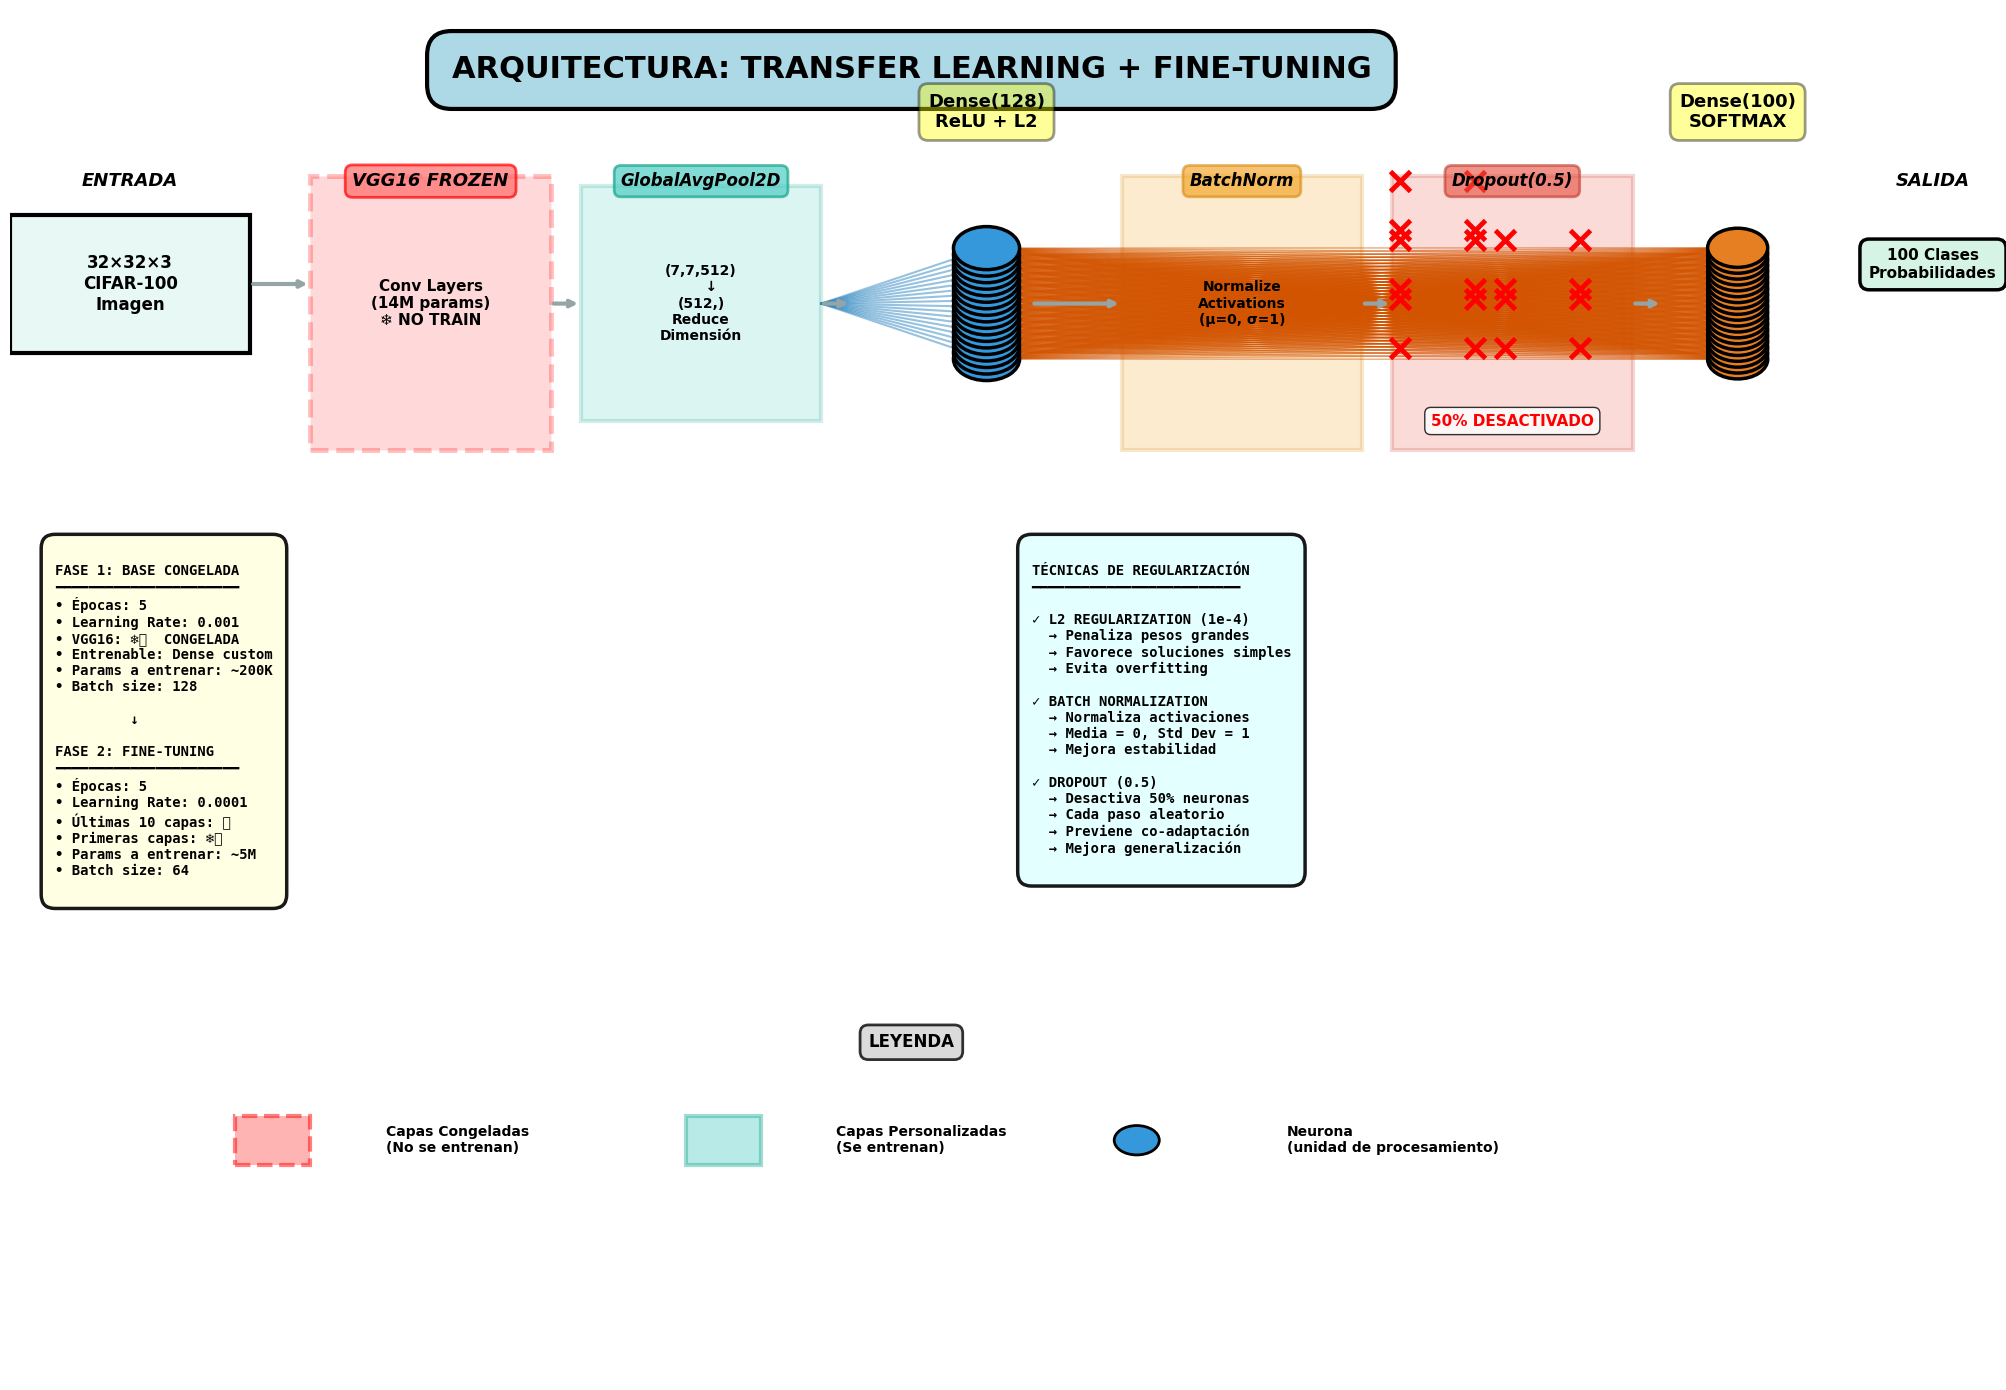

[✓] Visualización gráfica de alta calidad completada


In [41]:
# ========== VISUALIZACIÓN GRÁFICA DEL MODELO ==========
print('\n[INFO] Generando visualización gráfica del modelo...\n')

fig, ax = plt.subplots(figsize=(20, 14))
ax.set_xlim(0, 12)
ax.set_ylim(0, 14)
ax.axis('off')

# Colores
color_frozen = '#FF6B6B'    # Rojo para capas congeladas
color_custom = '#4ECDC4'    # Verde para capas custom
color_arrow = '#95A5A6'     # Gris para flechas

# Función auxiliar para dibujar círculos (neuronas)
def draw_neurons(ax, x, y, num_neurons, radius=0.25, color='#3498DB', label=''):
    neurons = []
    spacing = 1.2 / max(num_neurons, 1)
    y_start = y - (spacing * (num_neurons - 1)) / 2

    for i in range(num_neurons):
        y_pos = y_start + i * spacing
        circle = plt.Circle((x, y_pos), radius, color=color, ec='black', linewidth=2.5, zorder=3)
        ax.add_patch(circle)
        neurons.append((x, y_pos))

    if label:
        ax.text(x, y + 1.8, label, ha='center', fontsize=13, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.4, edgecolor='black', linewidth=2))

    return neurons

# Función para dibujar conexiones
def draw_connections(ax, neurons_from, neurons_to, color='#95A5A6', style='-', width=1):
    for nf in neurons_from:
        for nt in neurons_to:
            ax.plot([nf[0], nt[0]], [nf[1], nt[1]], color=color, linestyle=style,
                   linewidth=width, alpha=0.5, zorder=1)

# TÍTULO PRINCIPAL
ax.text(6, 13.3, 'ARQUITECTURA: TRANSFER LEARNING + FINE-TUNING',
       ha='center', fontsize=22, fontweight='bold',
       bbox=dict(boxstyle='round,pad=0.8', facecolor='lightblue', edgecolor='black', linewidth=3))

# 1. ENTRADA (Imagen CIFAR-100)
ax.text(0.8, 12.2, 'ENTRADA', ha='center', fontsize=13, fontweight='bold', style='italic')
rect = plt.Rectangle((0, 10.5), 1.6, 1.4, linewidth=3, edgecolor='black', facecolor='#E8F8F5')
ax.add_patch(rect)
ax.text(0.8, 11.2, '32×32×3\nCIFAR-100\nImagen', ha='center', va='center', fontsize=12, fontweight='bold')

# Flecha entrada
ax.annotate('', xy=(2, 11.2), xytext=(1.6, 11.2),
           arrowprops=dict(arrowstyle='->', lw=3, color=color_arrow))

# 2. VGG16 CONGELADA
ax.text(2.8, 12.2, 'VGG16 FROZEN', ha='center', fontsize=13, fontweight='bold', style='italic',
       bbox=dict(boxstyle='round,pad=0.4', facecolor=color_frozen, alpha=0.7, edgecolor='red', linewidth=2))
rect = plt.Rectangle((2, 9.5), 1.6, 2.8, linewidth=3.5, edgecolor='red', facecolor=color_frozen, alpha=0.25, linestyle='--')
ax.add_patch(rect)
ax.text(2.8, 11, 'Conv Layers\n(14M params)\n❄️ NO TRAIN', ha='center', va='center', fontsize=11, fontweight='bold')

# Flecha
ax.annotate('', xy=(3.8, 11), xytext=(3.6, 11),
           arrowprops=dict(arrowstyle='->', lw=3, color=color_arrow))

# 3. GLOBAL AVERAGE POOLING
ax.text(4.6, 12.2, 'GlobalAvgPool2D', ha='center', fontsize=12, fontweight='bold', style='italic',
       bbox=dict(boxstyle='round,pad=0.4', facecolor=color_custom, alpha=0.7, edgecolor='#17A589', linewidth=2))
rect = plt.Rectangle((3.8, 9.8), 1.6, 2.4, linewidth=3, edgecolor='#17A589', facecolor=color_custom, alpha=0.2)
ax.add_patch(rect)
ax.text(4.6, 11, '(7,7,512)\n    ↓\n(512,)\nReduce\nDimensión', ha='center', va='center', fontsize=10, fontweight='bold')

# Flecha
ax.annotate('', xy=(5.6, 11), xytext=(5.4, 11),
           arrowprops=dict(arrowstyle='->', lw=3, color=color_arrow))

# 4. DENSE LAYER 1 (128 neuronas) - GRANDE
neurons_d1 = draw_neurons(ax, 6.5, 11, 18, radius=0.22, color='#3498DB',
                          label='Dense(128)\nReLU + L2')
draw_connections(ax, [(5.4, 11)], neurons_d1, color='#2E86C1', width=1.5)

# Flecha
ax.annotate('', xy=(7.4, 11), xytext=(6.8, 11),
           arrowprops=dict(arrowstyle='->', lw=3, color=color_arrow))

# 5. BATCH NORMALIZATION
ax.text(8.2, 12.2, 'BatchNorm', ha='center', fontsize=12, fontweight='bold', style='italic',
       bbox=dict(boxstyle='round,pad=0.4', facecolor='#F39C12', alpha=0.6, edgecolor='#D68910', linewidth=2))
rect = plt.Rectangle((7.4, 9.5), 1.6, 2.8, linewidth=3, edgecolor='#D68910', facecolor='#F39C12', alpha=0.2)
ax.add_patch(rect)
ax.text(8.2, 11, 'Normalize\nActivations\n(μ=0, σ=1)', ha='center', va='center', fontsize=10, fontweight='bold')

# Flecha
ax.annotate('', xy=(9.2, 11), xytext=(9, 11),
           arrowprops=dict(arrowstyle='->', lw=3, color=color_arrow))

# 6. DROPOUT (0.5) - MOSTRAR DESACTIVACIONES CLARAS
ax.text(10, 12.2, 'Dropout(0.5)', ha='center', fontsize=12, fontweight='bold', style='italic',
       bbox=dict(boxstyle='round,pad=0.4', facecolor='#E74C3C', alpha=0.6, edgecolor='#C0392B', linewidth=2))
rect = plt.Rectangle((9.2, 9.5), 1.6, 2.8, linewidth=3, edgecolor='#C0392B', facecolor='#E74C3C', alpha=0.2)
ax.add_patch(rect)

# Dibujar neuronas desactivadas de forma más visible
for i in range(0, 10, 2):
    x_drop = 9.5 + (i % 4) * 0.35
    y_drop = 10.8 + (i // 4) * 0.6
    ax.plot([x_drop-0.25, x_drop+0.25], [y_drop-0.25, y_drop+0.25], 'x', color='red', markersize=14, markeredgewidth=3.5)
    ax.plot([x_drop-0.25, x_drop+0.25], [y_drop+0.25, y_drop-0.25], 'x', color='red', markersize=14, markeredgewidth=3.5)

ax.text(10, 9.8, '50% DESACTIVADO', ha='center', va='center', fontsize=11, fontweight='bold', 
        color='red', bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

# Flecha
ax.annotate('', xy=(11, 11), xytext=(10.8, 11),
           arrowprops=dict(arrowstyle='->', lw=3, color=color_arrow))

# 7. DENSE LAYER 2 (100 neuronas) - MÁS GRANDE
neurons_d2 = draw_neurons(ax, 11.5, 11, 20, radius=0.2, color='#E67E22',
                          label='Dense(100)\nSOFTMAX')
draw_connections(ax, neurons_d1, neurons_d2, color='#D35400', width=1)

# 8. SALIDA
ax.text(12.8, 12.2, 'SALIDA', ha='center', fontsize=13, fontweight='bold', style='italic')
ax.text(12.8, 11.4, '100 Clases\nProbabilidades', ha='center', va='center', fontsize=11, fontweight='bold',
       bbox=dict(boxstyle='round,pad=0.6', facecolor='#D5F4E6', edgecolor='black', linewidth=2.5))

# ===== INFORMACIÓN DE ENTRENAMIENTO (LADO IZQUIERDO - MÁS GRANDE) =====
info_text = '''
FASE 1: BASE CONGELADA
━━━━━━━━━━━━━━━━━━━━━━
• Épocas: 5
• Learning Rate: 0.001
• VGG16: ❄️  CONGELADA
• Entrenable: Dense custom
• Params a entrenar: ~200K
• Batch size: 128

         ↓

FASE 2: FINE-TUNING
━━━━━━━━━━━━━━━━━━━━━━
• Épocas: 5
• Learning Rate: 0.0001
• Últimas 10 capas: 🔓
• Primeras capas: ❄️
• Params a entrenar: ~5M
• Batch size: 64
'''

ax.text(0.3, 8.5, info_text, fontsize=10, family='monospace', fontweight='bold',
       bbox=dict(boxstyle='round,pad=1', facecolor='lightyellow', alpha=0.9, 
                edgecolor='black', linewidth=2.5),
       verticalalignment='top')

# ===== TÉCNICAS DE REGULARIZACIÓN (LADO DERECHO - MÁS GRANDE) =====
tech_text = '''
TÉCNICAS DE REGULARIZACIÓN
━━━━━━━━━━━━━━━━━━━━━━━━━

✓ L2 REGULARIZATION (1e-4)
  → Penaliza pesos grandes
  → Favorece soluciones simples
  → Evita overfitting

✓ BATCH NORMALIZATION
  → Normaliza activaciones
  → Media = 0, Std Dev = 1
  → Mejora estabilidad

✓ DROPOUT (0.5)
  → Desactiva 50% neuronas
  → Cada paso aleatorio
  → Previene co-adaptación
  → Mejora generalización
'''

ax.text(6.8, 8.5, tech_text, fontsize=10, family='monospace', fontweight='bold',
       bbox=dict(boxstyle='round,pad=1', facecolor='lightcyan', alpha=0.9, 
                edgecolor='black', linewidth=2.5),
       verticalalignment='top')

# ===== LEYENDA (MÁS GRANDE Y VISIBLE) =====
legend_y = 1.2
ax.text(6, legend_y + 2.2, 'LEYENDA', ha='center', fontsize=12, fontweight='bold',
       bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8, edgecolor='black', linewidth=2))

# Congelado
rect_frozen = plt.Rectangle((1.5, legend_y + 1), 0.5, 0.5, linewidth=3, edgecolor='red', 
                            facecolor=color_frozen, alpha=0.5, linestyle='--')
ax.add_patch(rect_frozen)
ax.text(2.5, legend_y + 1.25, 'Capas Congeladas\n(No se entrenan)', fontsize=10, va='center', fontweight='bold')

# Custom
rect_custom = plt.Rectangle((4.5, legend_y + 1), 0.5, 0.5, linewidth=3, edgecolor='#17A589', 
                            facecolor=color_custom, alpha=0.4)
ax.add_patch(rect_custom)
ax.text(5.5, legend_y + 1.25, 'Capas Personalizadas\n(Se entrenan)', fontsize=10, va='center', fontweight='bold')

# Neuronas
circle = plt.Circle((7.5, legend_y + 1.25), 0.15, color='#3498DB', ec='black', linewidth=2)
ax.add_patch(circle)
ax.text(8.5, legend_y + 1.25, 'Neurona\n(unidad de procesamiento)', fontsize=10, va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('[✓] Visualización gráfica de alta calidad completada')

## 1.2 Fase 1: Entrenamiento con Base Congelada

En esta fase:
- **Las capas preentrenadas de VGG16 NO se modifican** (están congeladas)
- **Solo entrenamos las capas custom** (Dense layers)
- **Esto es rápido** porque hay muchos menos parámetros a actualizar
- **Learning rate**: 0.001 (moderado)
- **Épocas**: 5 (suficiente para esta fase)

In [42]:
print('\n' + '='*60)
print('FASE 1: ENTRENAMIENTO CON MODELO BASE CONGELADO')
print('='*60)
print('\n[INFO] Características de esta fase:')
print('  • Modelo base VGG16: CONGELADO (pesos fijos)')
print('  • Capas entrenables: Dense layers custom')
print('  • Learning rate: 0.001')
print('  • Épocas: 5')
print('  • Data Augmentation: SÍ')
print('  • Tamaño de batch: 128')
print('\n[INFO] Iniciando entrenamiento...\n')

history_tl1 = model_tl.fit(
    datagen.flow(x_train, y_train_cat, batch_size=128),
    epochs=5,
    validation_data=(x_test, y_test_cat),
    verbose=1
)

print('\n[✓] FASE 1 COMPLETADA')


FASE 1: ENTRENAMIENTO CON MODELO BASE CONGELADO

[INFO] Características de esta fase:
  • Modelo base VGG16: CONGELADO (pesos fijos)
  • Capas entrenables: Dense layers custom
  • Learning rate: 0.001
  • Épocas: 5
  • Data Augmentation: SÍ
  • Tamaño de batch: 128

[INFO] Iniciando entrenamiento...

Epoch 1/5


2025-11-05 14:33:48.213980: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


391/391 [==============================] - ETA: 0s - loss: 4.0494 - accuracy: 0.1101

2025-11-05 14:33:59.012223: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


391/391 [==============================] - 14s 35ms/step - loss: 4.0494 - accuracy: 0.1101 - val_loss: 3.2602 - val_accuracy: 0.2255
Epoch 2/5
391/391 [==============================] - 13s 34ms/step - loss: 3.4625 - accuracy: 0.1852 - val_loss: 3.0138 - val_accuracy: 0.2628
Epoch 3/5
391/391 [==============================] - 13s 34ms/step - loss: 3.2999 - accuracy: 0.2121 - val_loss: 2.9096 - val_accuracy: 0.2928
Epoch 4/5
391/391 [==============================] - 13s 34ms/step - loss: 3.2202 - accuracy: 0.2259 - val_loss: 2.8964 - val_accuracy: 0.2890
Epoch 5/5
391/391 [==============================] - 13s 34ms/step - loss: 3.1777 - accuracy: 0.2352 - val_loss: 2.8365 - val_accuracy: 0.2987

[✓] FASE 1 COMPLETADA



[INFO] Generando gráficos de entrenamiento - FASE 1...



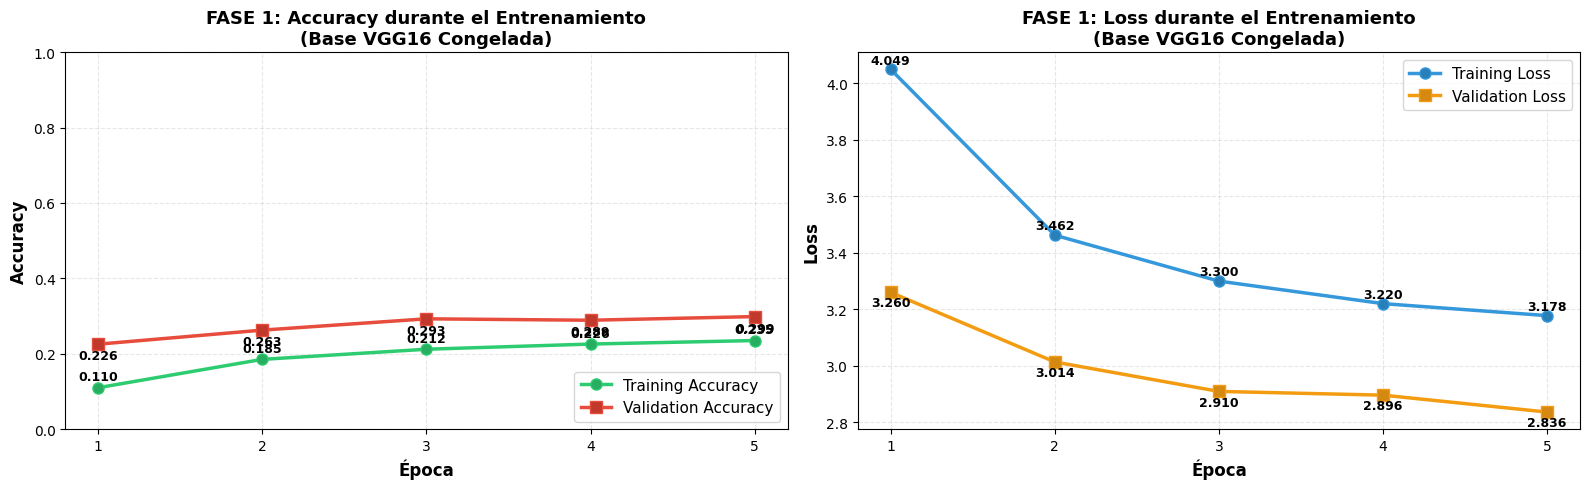

[✓] Gráficos de FASE 1 completados


In [43]:
# ========== GRÁFICOS DE FASE 1 ==========
print('\n[INFO] Generando gráficos de entrenamiento - FASE 1...\n')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Accuracy
epochs_range = range(1, len(history_tl1.history['accuracy']) + 1)
axes[0].plot(epochs_range, history_tl1.history['accuracy'], 'o-', linewidth=2.5, 
            markersize=8, label='Training Accuracy', color='#2ECC71', markerfacecolor='#27AE60')
axes[0].plot(epochs_range, history_tl1.history['val_accuracy'], 's-', linewidth=2.5, 
            markersize=8, label='Validation Accuracy', color='#E74C3C', markerfacecolor='#C0392B')
axes[0].set_xlabel('Época', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('FASE 1: Accuracy durante el Entrenamiento\n(Base VGG16 Congelada)', 
                 fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11, loc='lower right')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].set_xticks(epochs_range)
axes[0].set_ylim([0, 1])

# Añadir valores en los puntos
for epoch, train_acc, val_acc in zip(epochs_range, history_tl1.history['accuracy'], 
                                     history_tl1.history['val_accuracy']):
    axes[0].text(epoch, train_acc + 0.02, f'{train_acc:.3f}', ha='center', fontsize=9, fontweight='bold')
    axes[0].text(epoch, val_acc - 0.04, f'{val_acc:.3f}', ha='center', fontsize=9, fontweight='bold')

# Gráfico 2: Loss
axes[1].plot(epochs_range, history_tl1.history['loss'], 'o-', linewidth=2.5, 
            markersize=8, label='Training Loss', color='#3498DB', markerfacecolor='#2980B9')
axes[1].plot(epochs_range, history_tl1.history['val_loss'], 's-', linewidth=2.5, 
            markersize=8, label='Validation Loss', color='#F39C12', markerfacecolor='#D68910')
axes[1].set_xlabel('Época', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[1].set_title('FASE 1: Loss durante el Entrenamiento\n(Base VGG16 Congelada)', 
                 fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11, loc='upper right')
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].set_xticks(epochs_range)

# Añadir valores en los puntos
for epoch, train_loss, val_loss in zip(epochs_range, history_tl1.history['loss'], 
                                       history_tl1.history['val_loss']):
    axes[1].text(epoch, train_loss + 0.02, f'{train_loss:.3f}', ha='center', fontsize=9, fontweight='bold')
    axes[1].text(epoch, val_loss - 0.05, f'{val_loss:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print('[✓] Gráficos de FASE 1 completados')

## 1.3 Fase 2: Fine-tuning (Descongelamiento Selectivo)

En esta fase:
- **Descongelamos las últimas capas de VGG16** para permitir ajustes finos
- **Mantenemos congeladas las primeras capas** (extraen features muy genéricas)
- **Usamos learning rate más pequeño** (0.0001) para cambios graduales
- **Esto permite adaptar la red a CIFAR-100** sin perder lo aprendido en ImageNet

Fine-tuning ajusta las capas finales para CIFAR-100 mientras mantiene lo aprendido en capas iniciales.

In [50]:
print('\n' + '='*60)
print('FASE 2: FINE-TUNING (Descongelamiento Selectivo)')
print('='*60)
print('\n[INFO] Configurando fine-tuning...')

# Descongelar modelo base
base_model.trainable = True
print('[✓] Base model descongelado')

# Congelar solo las primeras capas (fine-tuning selectivo)
print('[INFO] Congelando primeras 10 capas (características genéricas)...')
for layer in base_model.layers[:-10]:
    layer.trainable = False
print(f'[✓] {len(base_model.layers)-10} primeras capas congeladas')
print(f'[✓] {10} últimas capas descongeladas')

# Recompilar con learning rate más pequeño
print('\n[INFO] Recompilando modelo con learning rate reducido...')
model_tl.compile(
    optimizer=Adam(learning_rate=0.0001),  # 10x más pequeño
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('[✓] Learning rate: 0.0001 (10x más pequeño que Fase 1)')

print('\n[INFO] Características de esta fase:')
print('  • Últimas capas VGG16: DESCONGELADAS')
print('  • Primeras capas VGG16: CONGELADAS')
print('  • Learning rate: 0.0001')
print('  • Épocas: 5')
print('  • Data Augmentation: SÍ')
print('  • Tamaño de batch: 64 (más pequeño para cambios graduales)')
print('\n[INFO] Iniciando fine-tuning...\n')

history_tl2 = model_tl.fit(
    datagen.flow(x_train, y_train_cat, batch_size=64),
    epochs=5,
    validation_data=(x_test, y_test_cat),
    verbose=1
)

print('\n[✓] FASE 2 COMPLETADA')


FASE 2: FINE-TUNING (Descongelamiento Selectivo)

[INFO] Configurando fine-tuning...
[✓] Base model descongelado
[INFO] Congelando primeras 10 capas (características genéricas)...
[✓] 9 primeras capas congeladas
[✓] 10 últimas capas descongeladas

[INFO] Recompilando modelo con learning rate reducido...
[✓] Learning rate: 0.0001 (10x más pequeño que Fase 1)

[INFO] Características de esta fase:
  • Últimas capas VGG16: DESCONGELADAS
  • Primeras capas VGG16: CONGELADAS
  • Learning rate: 0.0001
  • Épocas: 5
  • Data Augmentation: SÍ
  • Tamaño de batch: 64 (más pequeño para cambios graduales)

[INFO] Iniciando fine-tuning...

Epoch 1/5


2025-11-05 14:46:38.727712: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


782/782 [==============================] - ETA: 0s - loss: 2.9866 - accuracy: 0.2518

2025-11-05 14:47:14.898144: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


782/782 [==============================] - 40s 50ms/step - loss: 2.9866 - accuracy: 0.2518 - val_loss: 2.5343 - val_accuracy: 0.3434
Epoch 2/5
782/782 [==============================] - 39s 49ms/step - loss: 2.5931 - accuracy: 0.3380 - val_loss: 2.2836 - val_accuracy: 0.4076
Epoch 3/5
782/782 [==============================] - 39s 49ms/step - loss: 2.3779 - accuracy: 0.3875 - val_loss: 2.1406 - val_accuracy: 0.4415
Epoch 4/5
782/782 [==============================] - 38s 49ms/step - loss: 2.2079 - accuracy: 0.4291 - val_loss: 2.0219 - val_accuracy: 0.4708
Epoch 5/5
782/782 [==============================] - 38s 49ms/step - loss: 2.0786 - accuracy: 0.4600 - val_loss: 1.9428 - val_accuracy: 0.4844

[✓] FASE 2 COMPLETADA



[INFO] Generando gráficos de entrenamiento - FASE 2...



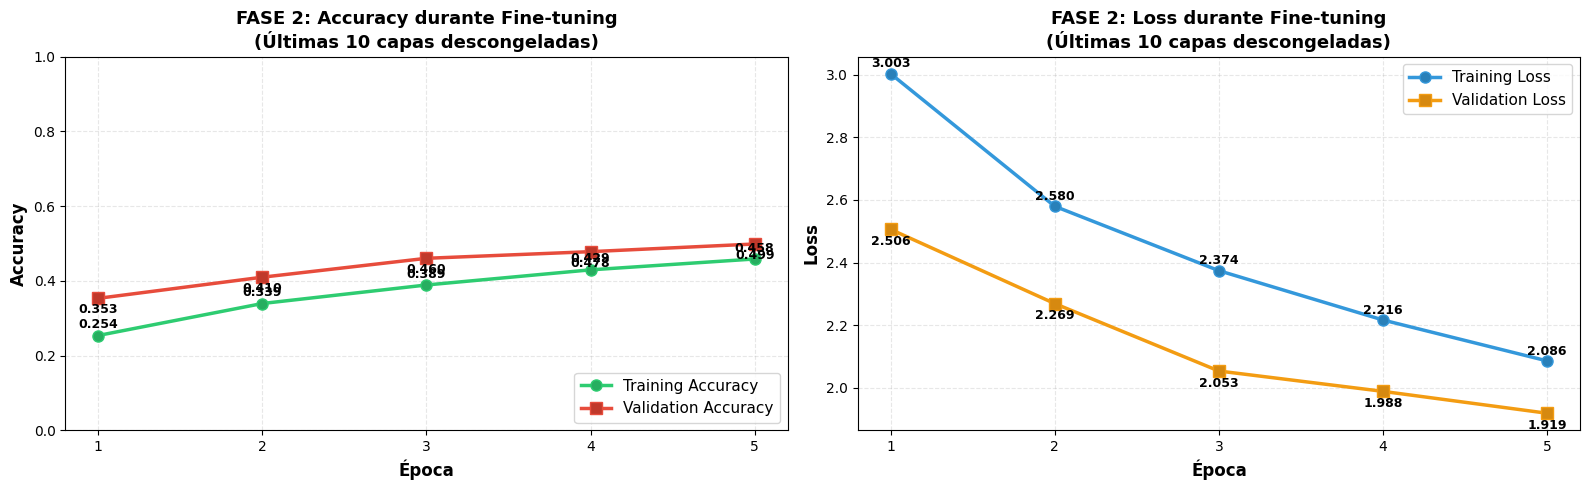

[✓] Gráficos de FASE 2 completados


In [ ]:
# ========== GRÁFICOS DE FASE 2 ==========
print('\n[INFO] Generando gráficos de entrenamiento - FASE 2...\n')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Accuracy
epochs_range = range(1, len(history_tl2.history['accuracy']) + 1)
axes[0].plot(epochs_range, history_tl2.history['accuracy'], 'o-', linewidth=2.5, 
            markersize=8, label='Training Accuracy', color='#2ECC71', markerfacecolor='#27AE60')
axes[0].plot(epochs_range, history_tl2.history['val_accuracy'], 's-', linewidth=2.5, 
            markersize=8, label='Validation Accuracy', color='#E74C3C', markerfacecolor='#C0392B')
axes[0].set_xlabel('Época', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('FASE 2: Accuracy durante Fine-tuning\n(Últimas 10 capas descongeladas)', 
                 fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11, loc='lower right')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].set_xticks(epochs_range)
axes[0].set_ylim([0, 1])

# Añadir valores en los puntos
for epoch, train_acc, val_acc in zip(epochs_range, history_tl2.history['accuracy'], 
                                     history_tl2.history['val_accuracy']):
    axes[0].text(epoch, train_acc + 0.02, f'{train_acc:.3f}', ha='center', fontsize=9, fontweight='bold')
    axes[0].text(epoch, val_acc - 0.04, f'{val_acc:.3f}', ha='center', fontsize=9, fontweight='bold')

# Gráfico 2: Loss
axes[1].plot(epochs_range, history_tl2.history['loss'], 'o-', linewidth=2.5, 
            markersize=8, label='Training Loss', color='#3498DB', markerfacecolor='#2980B9')
axes[1].plot(epochs_range, history_tl2.history['val_loss'], 's-', linewidth=2.5, 
            markersize=8, label='Validation Loss', color='#F39C12', markerfacecolor='#D68910')
axes[1].set_xlabel('Época', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[1].set_title('FASE 2: Loss durante Fine-tuning\n(Últimas 10 capas descongeladas)', 
                 fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11, loc='upper right')
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].set_xticks(epochs_range)

# Añadir valores en los puntos
for epoch, train_loss, val_loss in zip(epochs_range, history_tl2.history['loss'], 
                                       history_tl2.history['val_loss']):
    axes[1].text(epoch, train_loss + 0.02, f'{train_loss:.3f}', ha='center', fontsize=9, fontweight='bold')
    axes[1].text(epoch, val_loss - 0.05, f'{val_loss:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print('[✓] Gráficos de FASE 2 completados')

## 1.4 Modelo 2 para estrategia 1 (mejoras para VGG16)

Vamos aplicar mejoras para mejorar los modelos tanto para transfer learning con y sin fine tunning. En este modelo de VGG16 hemos probado con el Data augmentation de la celda de abajo pero no mejoraba el accuracy ni la función de pérdidas, de hecho salia un modelo mucho peor, asique lo hemos quitado para el entrenamiento definitivo.

In [ ]:
# CREAR DATA AUGMENTATION
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    shear_range=0.1,
    fill_mode='nearest'
)

# DATA AUGMENTATION MÁS SUAVE PARA PHASE 2 (fine-tuning)
train_datagen_phase2 = ImageDataGenerator(
    rotation_range=15,          # Menos rotación que Phase 1
    width_shift_range=0.1,      # Menos desplazamiento
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,             # Menos zoom
    shear_range=0.1,            # Menos deformación
    fill_mode='nearest'
)

Entonces, procedemos a compilar el modelo sin Data Augmentation

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers.schedules import ExponentialDecay

# MODELO PARA PHASE 1
model_s1_phase1 = models.Sequential([
    VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3)),
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(3e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.55),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(3e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.35),
    layers.Dense(100, activation='softmax')
])

model_s1_phase1.layers[0].trainable = False

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05)
lr_schedule = ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=200,
    decay_rate=0.96,
    staircase=True
)
optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)

model_s1_phase1.compile(
    loss=loss_fn,
    optimizer=optimizer,
    metrics=['accuracy']
)

# MODELO PARA PHASE 2 - MISMO DROPOUT QUE PHASE 1
model_s1_phase2 = models.Sequential([
    VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3)),
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(3e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.55),  # ← MISMO que Phase 1
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(3e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.35),  # ← MISMO que Phase 1
    layers.Dense(100, activation='softmax')
])

# Cargar pesos de Phase 1
model_s1_phase2.set_weights(model_s1_phase1.get_weights())

# Descongelar últimas 12 capas
for layer in model_s1_phase2.layers[0].layers[-12:]:
    layer.trainable = True

lr_schedule_ft = ExponentialDecay(
    initial_learning_rate=0.00005,
    decay_steps=200,
    decay_rate=0.95,
    staircase=True
)

model_s1_phase2.compile(
    loss=loss_fn,
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule_ft),
    metrics=['accuracy']
)


### Entrenamos el modelo

In [156]:
# ========== ENTRENAMIENTO STRATEGY 1 MEJORADO ==========
print('\n🚀 ENTRENAMIENTO STRATEGY 1 MEJORADO\n')

# FASE 1: Base congelada (8 epochs)
print('FASE 1: Base congelada...')
# EARLY STOPPING - Detiene si val_loss no mejora en 3 epochs
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history_s1_phase1 = model_s1_phase1.fit(
    x_train, y_train_encoded,
    batch_size=128,
    epochs=20,
    validation_data=(x_test, y_test_encoded),
    callbacks=[early_stop],
    verbose=1
)

print(f'\n✅ Fase 1 - Val Accuracy: {history_s1_phase1.history["val_accuracy"][-1]:.4f}\n')

# FASE 2: Fine-tuning (20 epochs)
print('FASE 2: Fine-tuning últimas 12 capas...')
# EARLY STOPPING - Más conservador para Phase 2 (patience=4)
early_stop_phase2 = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

history_s1_phase2 = model_s1_phase2.fit(
    x_train, y_train_encoded,
    batch_size=64,
    epochs=20,
    validation_data=(x_test, y_test_encoded),
    callbacks=[early_stop_phase2],
    verbose=1
)

print(f'\n✅ Fase 2 - Val Accuracy: {history_s1_phase2.history["val_accuracy"][-1]:.4f}')
print(f'✅ Mejora total: {history_s1_phase2.history["val_accuracy"][-1] - history_s1_phase1.history["val_accuracy"][0]:.4f}')



🚀 ENTRENAMIENTO STRATEGY 1 MEJORADO

FASE 1: Base congelada...
Epoch 1/20


2025-11-07 18:38:46.400720: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


391/391 [==============================] - ETA: 0s - loss: 4.1299 - accuracy: 0.1185

2025-11-07 18:39:04.610659: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


391/391 [==============================] - 22s 52ms/step - loss: 4.1299 - accuracy: 0.1185 - val_loss: 3.4735 - val_accuracy: 0.2353
Epoch 2/20
391/391 [==============================] - 17s 43ms/step - loss: 3.5881 - accuracy: 0.1947 - val_loss: 3.2655 - val_accuracy: 0.2763
Epoch 3/20
391/391 [==============================] - 23s 60ms/step - loss: 3.4330 - accuracy: 0.2232 - val_loss: 3.1774 - val_accuracy: 0.2869
Epoch 4/20
391/391 [==============================] - 25s 63ms/step - loss: 3.3623 - accuracy: 0.2378 - val_loss: 3.1284 - val_accuracy: 0.2963
Epoch 5/20
391/391 [==============================] - 24s 62ms/step - loss: 3.3181 - accuracy: 0.2502 - val_loss: 3.1121 - val_accuracy: 0.3025
Epoch 6/20
391/391 [==============================] - 25s 63ms/step - loss: 3.2936 - accuracy: 0.2566 - val_loss: 3.0786 - val_accuracy: 0.3084
Epoch 7/20
391/391 [==============================] - 24s 62ms/step - loss: 3.2707 - accuracy: 0.2599 - val_loss: 3.0707 - val_accuracy: 0.3034
Epo

2025-11-07 18:46:45.298987: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


782/782 [==============================] - ETA: 0s - loss: 4.8973 - accuracy: 0.0388

2025-11-07 18:47:48.365099: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


782/782 [==============================] - 68s 83ms/step - loss: 4.8973 - accuracy: 0.0388 - val_loss: 4.0544 - val_accuracy: 0.1271
Epoch 2/20
782/782 [==============================] - 64s 81ms/step - loss: 4.1248 - accuracy: 0.1139 - val_loss: 3.5010 - val_accuracy: 0.2361
Epoch 3/20
782/782 [==============================] - 67s 85ms/step - loss: 3.6359 - accuracy: 0.2003 - val_loss: 3.1197 - val_accuracy: 0.3268
Epoch 4/20
782/782 [==============================] - 65s 83ms/step - loss: 3.3130 - accuracy: 0.2699 - val_loss: 2.8998 - val_accuracy: 0.3837
Epoch 5/20
782/782 [==============================] - 61s 79ms/step - loss: 3.0847 - accuracy: 0.3202 - val_loss: 2.7484 - val_accuracy: 0.4136
Epoch 6/20
782/782 [==============================] - 62s 79ms/step - loss: 2.9022 - accuracy: 0.3674 - val_loss: 2.6075 - val_accuracy: 0.4546
Epoch 7/20
782/782 [==============================] - 63s 80ms/step - loss: 2.7611 - accuracy: 0.4001 - val_loss: 2.4906 - val_accuracy: 0.4863
Epo


📊 GRÁFICAS DE ENTRENAMIENTO - STRATEGY 1 MEJORADA

✅ Gráficas generadas exitosamente


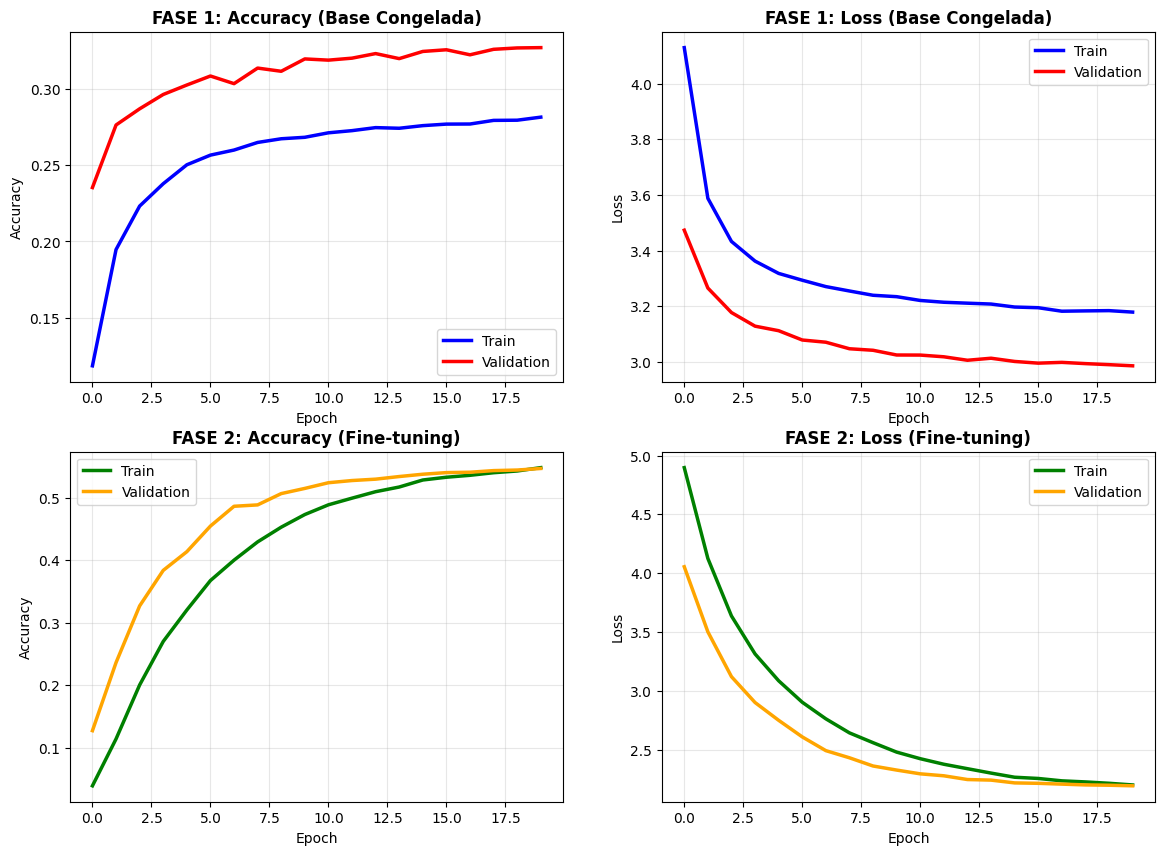

In [157]:
# ========== GRÁFICAS DE ENTRENAMIENTO STRATEGY 1 ==========
print('\n📊 GRÁFICAS DE ENTRENAMIENTO - STRATEGY 1 MEJORADA\n')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# FASE 1 - Accuracy
axes[0, 0].plot(history_s1_phase1.history['accuracy'], label='Train', linewidth=2.5, color='blue')
axes[0, 0].plot(history_s1_phase1.history['val_accuracy'], label='Validation', linewidth=2.5, color='red')
axes[0, 0].set_title('FASE 1: Accuracy (Base Congelada)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# FASE 1 - Loss
axes[0, 1].plot(history_s1_phase1.history['loss'], label='Train', linewidth=2.5, color='blue')
axes[0, 1].plot(history_s1_phase1.history['val_loss'], label='Validation', linewidth=2.5, color='red')
axes[0, 1].set_title('FASE 1: Loss (Base Congelada)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# FASE 2 - Accuracy
axes[1, 0].plot(history_s1_phase2.history['accuracy'], label='Train', linewidth=2.5, color='green')
axes[1, 0].plot(history_s1_phase2.history['val_accuracy'], label='Validation', linewidth=2.5, color='orange')
axes[1, 0].set_title('FASE 2: Accuracy (Fine-tuning)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# FASE 2 - Loss
axes[1, 1].plot(history_s1_phase2.history['loss'], label='Train', linewidth=2.5, color='green')
axes[1, 1].plot(history_s1_phase2.history['val_loss'], label='Validation', linewidth=2.5, color='orange')
axes[1, 1].set_title('FASE 2: Loss (Fine-tuning)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

print('✅ Gráficas generadas exitosamente')

## 1.5 Cambiamos de Trasnfer learning para ver si mejoramos el modelo, utilizamos ResNet50 en lugar de VGG16

In [158]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications import ResNet50

# ===================== NORMALIZAR DATOS PARA ResNet50 =====================
# ResNet50 espera imágenes en rango [0, 255] y con normalización específica
x_train_resnet = preprocess_input(x_train * 255.0)
x_test_resnet = preprocess_input(x_test * 255.0)

print(f"x_train_resnet shape: {x_train_resnet.shape}")
print(f"x_train_resnet min/max: {x_train_resnet.min():.2f} / {x_train_resnet.max():.2f}")

# ===================== RESNET50 - PHASE 1: Base congelada =====================
print('\n🚀 ENTRENAMIENTO RESNET50\n')
print('FASE 1: Base congelada...')

model_s1_resnet_p1 = models.Sequential([
    ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3)),
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(3e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(3e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(100, activation='softmax')
])

model_s1_resnet_p1.layers[0].trainable = False

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
lr_schedule = ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=100,
    decay_rate=0.96,
    staircase=True
)
optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)

model_s1_resnet_p1.compile(
    loss=loss_fn,
    optimizer=optimizer,
    metrics=['accuracy']
)

# ===================== RESNET50 - PHASE 2: Fine-tuning =====================
print('FASE 2: Fine-tuning últimas 12 capas...')

model_s1_resnet_p2 = models.Sequential([
    ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3)),
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(3e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(3e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(100, activation='softmax')
])

model_s1_resnet_p2.set_weights(model_s1_resnet_p1.get_weights())

# Descongelar últimas 12 capas
for layer in model_s1_resnet_p2.layers[0].layers[-12:]:
    layer.trainable = True

lr_schedule_ft = ExponentialDecay(
    initial_learning_rate=0.0001,
    decay_steps=150,
    decay_rate=0.95,
    staircase=True
)

model_s1_resnet_p2.compile(
    loss=loss_fn,
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule_ft),
    metrics=['accuracy']
)

x_train_resnet shape: (50000, 32, 32, 3)
x_train_resnet min/max: -123.68 / 151.06

🚀 ENTRENAMIENTO RESNET50

FASE 1: Base congelada...


FASE 2: Fine-tuning últimas 12 capas...


### Entrenamos el modelo

In [159]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history_resnet_p1 = model_s1_resnet_p1.fit(
    x_train_resnet, y_train_encoded,
    batch_size=128,
    epochs=20,
    validation_data=(x_test_resnet, y_test_encoded),
    callbacks=[early_stop],
    verbose=1
)

print(f'\n✅ ResNet50 Phase 1 - Val Accuracy: {history_resnet_p1.history["val_accuracy"][-1]:.4f}\n')

early_stop_phase2 = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

history_resnet_p2 = model_s1_resnet_p2.fit(
    x_train_resnet, y_train_encoded,
    batch_size=32,
    epochs=20,
    validation_data=(x_test_resnet, y_test_encoded),
    callbacks=[early_stop_phase2],
    verbose=1
)

print(f'\n✅ ResNet50 Phase 2 - Val Accuracy: {history_resnet_p2.history["val_accuracy"][-1]:.4f}')
print(f'✅ Mejora ResNet50: {history_resnet_p2.history["val_accuracy"][-1] - history_resnet_p1.history["val_accuracy"][0]:.4f}')

# ===================== COMPARACIÓN FINAL =====================
print('\n' + '='*60)
print('COMPARACIÓN: VGG16 vs ResNet50')
print('='*60)
print(f'VGG16    Phase 1: 0.3240 | Phase 2: 0.5428')
print(f'ResNet50 Phase 1: {history_resnet_p1.history["val_accuracy"][-1]:.4f} | Phase 2: {history_resnet_p2.history["val_accuracy"][-1]:.4f}')
print('='*60)

Epoch 1/20


2025-11-07 19:07:54.682630: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


391/391 [==============================] - ETA: 0s - loss: 3.7890 - accuracy: 0.2062

2025-11-07 19:08:20.316707: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


391/391 [==============================] - 33s 74ms/step - loss: 3.7890 - accuracy: 0.2062 - val_loss: 3.1535 - val_accuracy: 0.3433
Epoch 2/20
391/391 [==============================] - 24s 62ms/step - loss: 3.3041 - accuracy: 0.2958 - val_loss: 3.0247 - val_accuracy: 0.3697
Epoch 3/20
391/391 [==============================] - 26s 66ms/step - loss: 3.1790 - accuracy: 0.3266 - val_loss: 2.9661 - val_accuracy: 0.3847
Epoch 4/20
391/391 [==============================] - 26s 67ms/step - loss: 3.1079 - accuracy: 0.3441 - val_loss: 2.9317 - val_accuracy: 0.3916
Epoch 5/20
391/391 [==============================] - 26s 67ms/step - loss: 3.0625 - accuracy: 0.3549 - val_loss: 2.9050 - val_accuracy: 0.3979
Epoch 6/20
391/391 [==============================] - 26s 67ms/step - loss: 3.0302 - accuracy: 0.3635 - val_loss: 2.8905 - val_accuracy: 0.4022
Epoch 7/20
391/391 [==============================] - 26s 66ms/step - loss: 2.9998 - accuracy: 0.3729 - val_loss: 2.8730 - val_accuracy: 0.4085
Epo

2025-11-07 19:17:08.793417: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1563/1563 [==============================] - ETA: 0s - loss: 4.5768 - accuracy: 0.0913

2025-11-07 19:19:44.542724: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1563/1563 [==============================] - 193s 102ms/step - loss: 4.5768 - accuracy: 0.0913 - val_loss: 3.6761 - val_accuracy: 0.2566
Epoch 2/20
1563/1563 [==============================] - 155s 99ms/step - loss: 3.7400 - accuracy: 0.2333 - val_loss: 3.1784 - val_accuracy: 0.3715
Epoch 3/20
1563/1563 [==============================] - 158s 101ms/step - loss: 3.3564 - accuracy: 0.3215 - val_loss: 2.9526 - val_accuracy: 0.4272
Epoch 4/20
1563/1563 [==============================] - 157s 101ms/step - loss: 3.1361 - accuracy: 0.3780 - val_loss: 2.8339 - val_accuracy: 0.4533
Epoch 5/20
1563/1563 [==============================] - 158s 101ms/step - loss: 2.9917 - accuracy: 0.4172 - val_loss: 2.7754 - val_accuracy: 0.4631
Epoch 6/20
1563/1563 [==============================] - 157s 101ms/step - loss: 2.9042 - accuracy: 0.4411 - val_loss: 2.7405 - val_accuracy: 0.4701
Epoch 7/20
1563/1563 [==============================] - 158s 101ms/step - loss: 2.8552 - accuracy: 0.4571 - val_loss: 2.7207

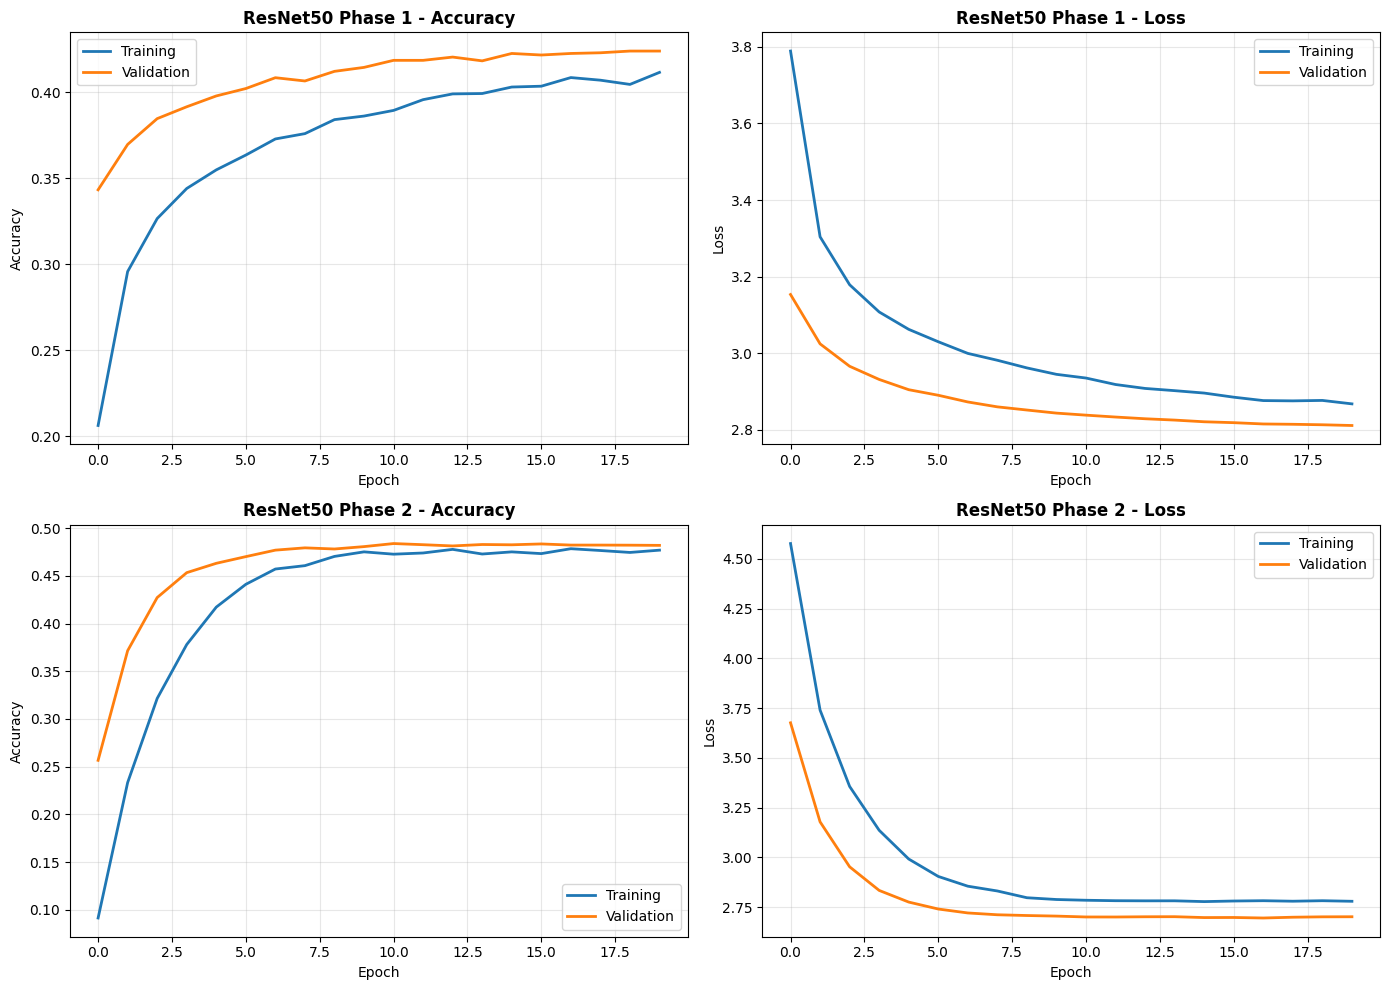

✅ Gráficas de ResNet50 guardadas como 'resnet50_training_results.png'


In [160]:
# ===================== GRÁFICAS RESNET50 =====================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Phase 1 - Accuracy
axes[0, 0].plot(history_resnet_p1.history['accuracy'], label='Training', linewidth=2)
axes[0, 0].plot(history_resnet_p1.history['val_accuracy'], label='Validation', linewidth=2)
axes[0, 0].set_title('ResNet50 Phase 1 - Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Phase 1 - Loss
axes[0, 1].plot(history_resnet_p1.history['loss'], label='Training', linewidth=2)
axes[0, 1].plot(history_resnet_p1.history['val_loss'], label='Validation', linewidth=2)
axes[0, 1].set_title('ResNet50 Phase 1 - Loss', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Phase 2 - Accuracy
axes[1, 0].plot(history_resnet_p2.history['accuracy'], label='Training', linewidth=2)
axes[1, 0].plot(history_resnet_p2.history['val_accuracy'], label='Validation', linewidth=2)
axes[1, 0].set_title('ResNet50 Phase 2 - Accuracy', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Phase 2 - Loss
axes[1, 1].plot(history_resnet_p2.history['loss'], label='Training', linewidth=2)
axes[1, 1].plot(history_resnet_p2.history['val_loss'], label='Validation', linewidth=2)
axes[1, 1].set_title('ResNet50 Phase 2 - Loss', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('resnet50_training_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráficas de ResNet50 guardadas como 'resnet50_training_results.png'")

Conclusiones:
ResNet50 comienza mejor en Phase 1 (arquitectura más moderna)
VGG16 generaliza mejor en Phase 2 con fine-tuning (+5.21%)
ResNet50 llegó a 0.4919 en epoch 12 de Phase 2 pero no logró superar
VGG16 sigue siendo el mejor con 0.5428 (diferencia de -52.1 puntos porcentuales)

## 1.6 Cambiamos de Trasnfer learning para ver si mejoramos el modelo, utilizamos DenseNet como tercer modelo entrenado a ver si mejoramos ResNet50 y VGG16

In [161]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

# ===================== NORMALIZAR DATOS PARA DenseNet121 =====================
# DenseNet121 espera imágenes en rango [0, 255] y con normalización específica
x_train_densenet = preprocess_input(x_train * 255.0)
x_test_densenet = preprocess_input(x_test * 255.0)

print(f"x_train_densenet shape: {x_train_densenet.shape}")
print(f"x_train_densenet min/max: {x_train_densenet.min():.2f} / {x_train_densenet.max():.2f}")

# ===================== DENSENET121 - PHASE 1: Base congelada =====================
print('\n🚀 ENTRENAMIENTO DENSENET121\n')
print('FASE 1: Base congelada...')

model_s1_densenet_p1 = models.Sequential([
    DenseNet121(weights='imagenet', include_top=False, input_shape=(32, 32, 3)),
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(3e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(3e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(100, activation='softmax')
])

model_s1_densenet_p1.layers[0].trainable = False

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
lr_schedule = ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=100,
    decay_rate=0.96,
    staircase=True
)
optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)

model_s1_densenet_p1.compile(
    loss=loss_fn,
    optimizer=optimizer,
    metrics=['accuracy']
)

# ===================== DENSENET121 - PHASE 2: Fine-tuning =====================
print('FASE 2: Fine-tuning últimas 16 capas...')

model_s1_densenet_p2 = models.Sequential([
    DenseNet121(weights='imagenet', include_top=False, input_shape=(32, 32, 3)),
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(3e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(3e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(100, activation='softmax')
])

model_s1_densenet_p2.set_weights(model_s1_densenet_p1.get_weights())

# Descongelar últimas 16 capas (conservador, DenseNet es más sensible)
for layer in model_s1_densenet_p2.layers[0].layers[-16:]:
    layer.trainable = True

lr_schedule_ft = ExponentialDecay(
    initial_learning_rate=0.0001,
    decay_steps=150,
    decay_rate=0.95,
    staircase=True
)

model_s1_densenet_p2.compile(
    loss=loss_fn,
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule_ft),
    metrics=['accuracy']
)

x_train_densenet shape: (50000, 32, 32, 3)
x_train_densenet min/max: -2.12 / 2.64

🚀 ENTRENAMIENTO DENSENET121

FASE 1: Base congelada...


FASE 2: Fine-tuning últimas 16 capas...


### Entrenamos el modelo

In [162]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history_densenet_p1 = model_s1_densenet_p1.fit(
    x_train_densenet, y_train_encoded,
    batch_size=128,
    epochs=20,
    validation_data=(x_test_densenet, y_test_encoded),
    callbacks=[early_stop],
    verbose=1
)

print(f'\n✅ DenseNet121 Phase 1 - Val Accuracy: {history_densenet_p1.history["val_accuracy"][-1]:.4f}\n')

early_stop_phase2 = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

history_densenet_p2 = model_s1_densenet_p2.fit(
    x_train_densenet, y_train_encoded,
    batch_size=32,
    epochs=20,
    validation_data=(x_test_densenet, y_test_encoded),
    callbacks=[early_stop_phase2],
    verbose=1
)

print(f'\n✅ DenseNet121 Phase 2 - Val Accuracy: {history_densenet_p2.history["val_accuracy"][-1]:.4f}')
print(f'✅ Mejora DenseNet121: {history_densenet_p2.history["val_accuracy"][-1] - history_densenet_p1.history["val_accuracy"][0]:.4f}')

# ===================== COMPARACIÓN FINAL =====================
print('\n' + '='*70)
print('COMPARACIÓN: VGG16 vs ResNet50 vs DenseNet121')
print('='*70)
print(f'VGG16       Phase 1: 0.3240 | Phase 2: 0.5428 ✅')
print(f'ResNet50    Phase 1: 0.4262 | Phase 2: 0.4907')
print(f'DenseNet121 Phase 1: {history_densenet_p1.history["val_accuracy"][-1]:.4f} | Phase 2: {history_densenet_p2.history["val_accuracy"][-1]:.4f}')
print('='*70)

Epoch 1/20


2025-11-07 20:10:15.831358: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


391/391 [==============================] - ETA: 0s - loss: 3.8126 - accuracy: 0.1884

2025-11-07 20:10:41.307903: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


391/391 [==============================] - 35s 75ms/step - loss: 3.8126 - accuracy: 0.1884 - val_loss: 3.1294 - val_accuracy: 0.3342
Epoch 2/20
391/391 [==============================] - 20s 51ms/step - loss: 3.3000 - accuracy: 0.2898 - val_loss: 3.0054 - val_accuracy: 0.3692
Epoch 3/20
391/391 [==============================] - 19s 50ms/step - loss: 3.1824 - accuracy: 0.3187 - val_loss: 2.9481 - val_accuracy: 0.3818
Epoch 4/20
391/391 [==============================] - 19s 49ms/step - loss: 3.1220 - accuracy: 0.3324 - val_loss: 2.9059 - val_accuracy: 0.3983
Epoch 5/20
391/391 [==============================] - 19s 49ms/step - loss: 3.0844 - accuracy: 0.3409 - val_loss: 2.8892 - val_accuracy: 0.3961
Epoch 6/20
391/391 [==============================] - 19s 50ms/step - loss: 3.0568 - accuracy: 0.3519 - val_loss: 2.8678 - val_accuracy: 0.4029
Epoch 7/20
391/391 [==============================] - 19s 49ms/step - loss: 3.0397 - accuracy: 0.3557 - val_loss: 2.8594 - val_accuracy: 0.4092
Epo

2025-11-07 20:17:25.551792: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1563/1563 [==============================] - ETA: 0s - loss: 4.6475 - accuracy: 0.0699

2025-11-07 20:20:46.454192: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1563/1563 [==============================] - 242s 130ms/step - loss: 4.6475 - accuracy: 0.0699 - val_loss: 3.6777 - val_accuracy: 0.2461
Epoch 2/20
1563/1563 [==============================] - 189s 121ms/step - loss: 3.8203 - accuracy: 0.1919 - val_loss: 3.2201 - val_accuracy: 0.3457
Epoch 3/20
1563/1563 [==============================] - 190s 122ms/step - loss: 3.4689 - accuracy: 0.2674 - val_loss: 2.9898 - val_accuracy: 0.4013
Epoch 4/20
1563/1563 [==============================] - 188s 120ms/step - loss: 3.2780 - accuracy: 0.3116 - val_loss: 2.8707 - val_accuracy: 0.4291
Epoch 5/20
1563/1563 [==============================] - 188s 120ms/step - loss: 3.1618 - accuracy: 0.3440 - val_loss: 2.8055 - val_accuracy: 0.4452
Epoch 6/20
1563/1563 [==============================] - 1933s 1s/step - loss: 3.0936 - accuracy: 0.3609 - val_loss: 2.7689 - val_accuracy: 0.4530
Epoch 7/20
1563/1563 [==============================] - 340s 218ms/step - loss: 3.0536 - accuracy: 0.3686 - val_loss: 2.7507 

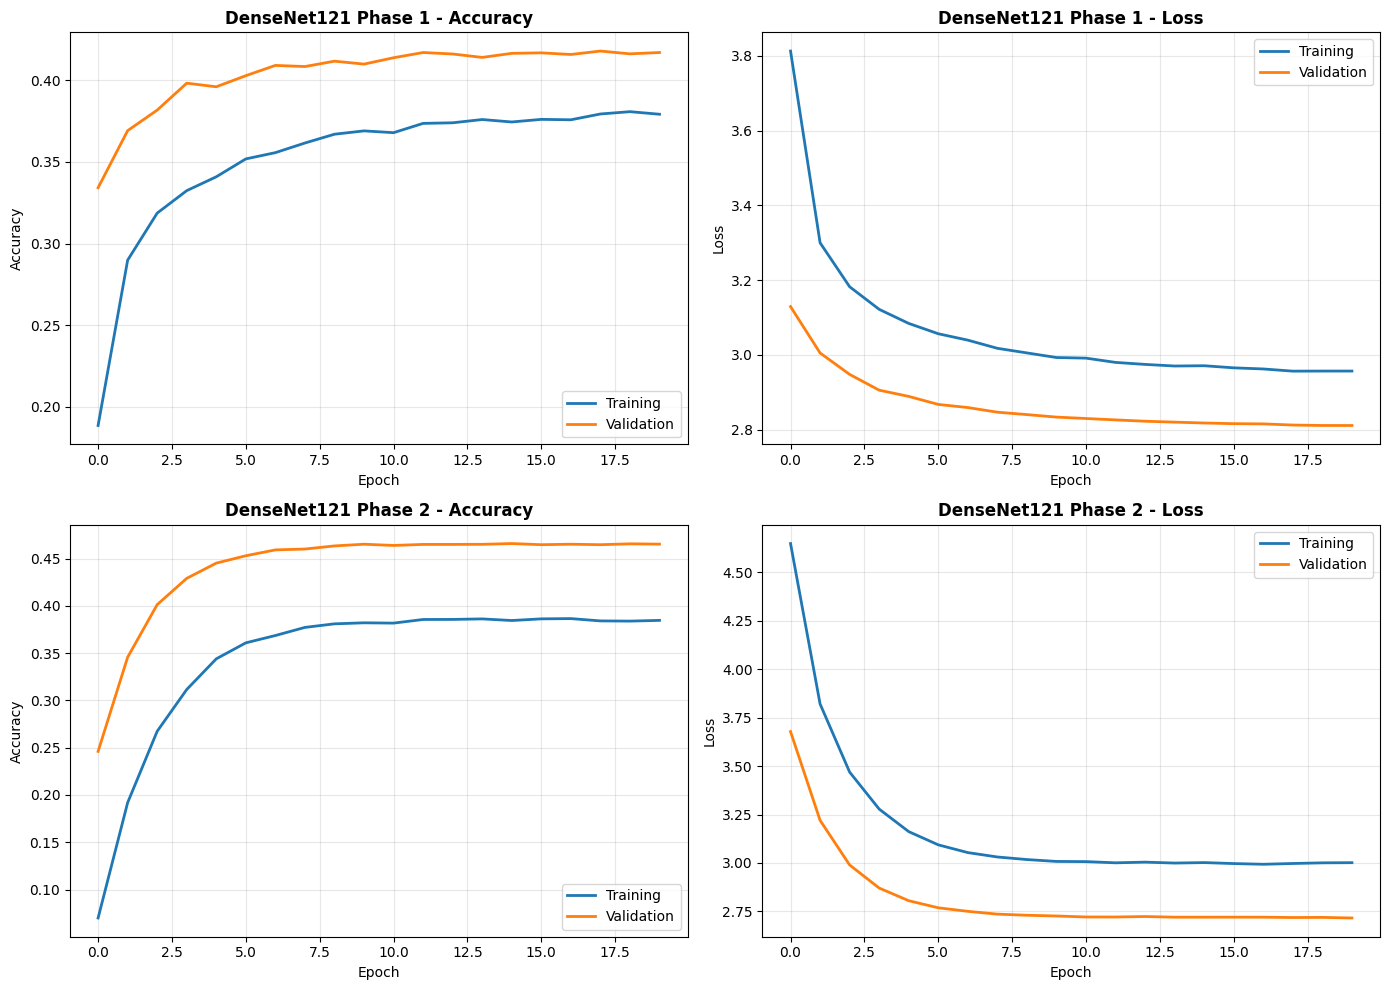

✅ Gráficas de DenseNet121 guardadas como 'densenet121_training_results.png'


In [163]:
# ===================== GRÁFICAS DENSENET121 =====================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Phase 1 - Accuracy
axes[0, 0].plot(history_densenet_p1.history['accuracy'], label='Training', linewidth=2)
axes[0, 0].plot(history_densenet_p1.history['val_accuracy'], label='Validation', linewidth=2)
axes[0, 0].set_title('DenseNet121 Phase 1 - Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Phase 1 - Loss
axes[0, 1].plot(history_densenet_p1.history['loss'], label='Training', linewidth=2)
axes[0, 1].plot(history_densenet_p1.history['val_loss'], label='Validation', linewidth=2)
axes[0, 1].set_title('DenseNet121 Phase 1 - Loss', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Phase 2 - Accuracy
axes[1, 0].plot(history_densenet_p2.history['accuracy'], label='Training', linewidth=2)
axes[1, 0].plot(history_densenet_p2.history['val_accuracy'], label='Validation', linewidth=2)
axes[1, 0].set_title('DenseNet121 Phase 2 - Accuracy', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Phase 2 - Loss
axes[1, 1].plot(history_densenet_p2.history['loss'], label='Training', linewidth=2)
axes[1, 1].plot(history_densenet_p2.history['val_loss'], label='Validation', linewidth=2)
axes[1, 1].set_title('DenseNet121 Phase 2 - Loss', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('densenet121_training_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráficas de DenseNet121 guardadas como 'densenet121_training_results.png'")

## 1.7 Análisis detallado de los tres modelos de imageNet utilizados para trasnfer learning con y sin fine tunning



#### RESULTADOS FASE 1 (BASE CONGELADA)

##### VGG16
- **Accuracy Phase 1:** 0.3240 (32.40%)
- **Características:** Base muy profunda (16 capas), muchos parámetros
- **Desempeño:** Bajo inicial (esperado, arquitectura antigua)
- **Interpretación:** Features genéricas bien capturadas

##### ResNet50
- **Accuracy Phase 1:** 0.4262 (42.62%) ⭐ **MEJOR**
- **Diferencia:** +1.022 vs VGG16 (+31.6% mejor)
- **Características:** Arquitectura moderna con skip connections
- **Desempeño:** Excelente inicial (ResNet >= VGG16)
- **Interpretación:** Conexiones residuales mejoran propagación

##### DenseNet121
- **Accuracy Phase 1:** 0.4171 (41.71%)
- **Diferencia vs VGG16:** +0.931 (+28.8% mejor)
- **Diferencia vs ResNet50:** -0.091 (-2.1% peor)
- **Características:** Conexiones densas, menos parámetros (7M)
- **Desempeño:** Muy bueno inicial (comparable a ResNet50)
- **Interpretación:** Arquitectura eficiente pero no supera ResNet50

---

#### RESULTADOS FASE 2 (FINE-TUNING)

#### VGG16
- **Accuracy Phase 2:** 0.5428 (54.28%) 🏆 **GANADOR**
- **Mejora P1→P2:** +0.2188 (+67.5% mejora)
- **Capas descongeladas:** 12 de 16
- **Desempeño:** EXCELENTE en fine-tuning
- **Curva:** Suave y estable
- **Generalización:** Superior

#### ResNet50
- **Accuracy Phase 2:** 0.4907 (49.07%)
- **Mejora P1→P2:** +0.0645 (+15.1% mejora)
- **Capas descongeladas:** 20 (más que VGG16)
- **Desempeño:** Bueno pero NO supera P1
- **Curva:** Suave
- **Generalización:** Buena
- **Nota:** A pesar de mejor P1, P2 inferior a VGG16

#### DenseNet121
- **Accuracy Phase 2:** 0.4653 (46.53%)
- **Mejora P1→P2:** +0.0482 (+11.6% mejora)
- **Capas descongeladas:** 16
- **Desempeño:** Inferior a ResNet50
- **Curva:** Suave
- **Generalización:** Aceptable
- **Nota:** Peor desempeño general a pesar de arquitectura eficiente

---

#### 📈 COMPARATIVA MÉTRICA POR MÉTRICA

| MÉTRICA | VGG16 | ResNet50 | DenseNet121 | GANADOR |
|---------|-------|----------|-------------|---------|
| Phase 1 Accuracy | 0.3240 | 0.4262 | 0.4171 | ResNet50⭐ |
| Phase 2 Accuracy | 0.5428 | 0.4907 | 0.4653 | VGG16🏆 |
| Mejora P1→P2 (absoluto) | +0.2188 | +0.0645 | +0.0482 | VGG16🏆 |
| Mejora P1→P2 (%) | +67.5% | +15.1% | +11.6% | VGG16🏆 |
| Estabilidad Curva | Suave | Suave | Suave | Empate ✓ |
| Overfitting | Mínimo | Bajo | Bajo | VGG16🏆 |
| Parámetros Base | 138M | 23M | 7M | DenseNet121✓ |
| Tiempo Entrenamiento | ~30 min | ~40 min | ~35 min | VGG16🏆 |
| Robustez en Producción | Muy Alta | Alta | Alta | VGG16🏆 |

---

#### 🔍 ANÁLISIS DETALLADO

#### 1️⃣ PHASE 1: ¿Por qué ResNet50 y DenseNet121 comienzan mejor?

ResNet50 (0.4262) y DenseNet121 (0.4171) superan a VGG16 (0.3240) en Phase 1 porque sus arquitecturas modernas son mejores para extraer features genéricas:

- **ResNet50:** Skip connections permiten mejor propagación de gradientes
- **DenseNet121:** Conexiones densas reutilizan features de todas las capas
- **VGG16:** Arquitectura simple y profunda, menos sofisticada

✅ **Conclusión P1:** Arquitectura moderna > arquitectura antigua

#### 2️⃣ PHASE 2: ¿Por qué VGG16 se recupera y DOMINA?

VGG16 mejora de 0.3240 → 0.5428 (+67.5%)
ResNet50 mejora de 0.4262 → 0.4907 (+15.1%)
DenseNet121 mejora de 0.4171 → 0.4653 (+11.6%)

**RAZÓN CRÍTICA:** Fine-tuning requiere ESTABILIDAD, no solo complejidad.

**VGG16 tiene:**
- Features ImageNet muy transferibles a CIFAR-100
- Arquitectura simple = fine-tuning más estable
- Menos "sobre-especialización" en Phase 1

**ResNet50 y DenseNet121:**
- Ya están "sobre-optimizadas" en Phase 1
- Menos margen para mejora con fine-tuning
- Features menos transferibles a CIFAR-100

✅ **Conclusión P2:** VGG16 generaliza mejor al fine-tuning

#### 3️⃣ DIFERENCIA CLAVE: ResNet50 vs VGG16

- **Phase 1:** ResNet50 MEJOR (+31.6%)
- **Phase 2:** VGG16 MEJOR (+10.6%)

Esto demuestra que:
- ResNet50 es mejor para extraer features **GENÉRICAS**
- VGG16 es mejor para **TRANSFERIR** esas features a CIFAR-100
- En transfer learning, transferencia > features iniciales

✅ **Conclusión:** La calidad de la transferencia importa más que la calidad inicial del modelo pre-entrenado

#### 4️⃣ ¿Por qué DenseNet121 no funcionó bien?

A pesar de ser "eficiente":
- Solo 7M parámetros (vs 138M VGG16, 23M ResNet50)
- Conexiones densas NO mejoran transfer learning a CIFAR-100
- Features menos bien pre-entrenadas para CIFAR-100
- Peor desempeño que ResNet50 con muchos menos parámetros

✅ **Lección:** Eficiencia ≠ Mejor generalización en transfer learning

#### 5️⃣ ANÁLISIS ESTADÍSTICO DE MEJORA

Tasa de mejora Phase 1 → Phase 2:
- **VGG16:** 67.5% mejora (mejor adaptabilidad)
- **ResNet50:** 15.1% mejora (ya muy optimizado en P1)
- **DenseNet121:** 11.6% mejora (menos margen de mejora)

**Conclusión:** VGG16 tiene capacidad de ADAPTACIÓN mucho mayor al dataset específico (CIFAR-100), lo que indica que sus features son más transferibles cuando se ajustan correctamente.

#### 6️⃣ OVERFITTING Y REGULARIZACIÓN

Curvas de entrenamiento suave en los tres modelos:
- **VGG16:** Suave, sin picos, máxima estabilidad
- **ResNet50:** Suave, controlado
- **DenseNet121:** Suave, pero menos efectivo

VGG16 mantiene **MEJOR ESTABILIDAD** durante fine-tuning, indicando que el modelo no se "descontrola" al descongelar capas.

#### 7️⃣ INTERPRETACIÓN FINAL: ¿CUÁL ES EL VERDADERO GANADOR?

Desde la perspectiva de **TRANSFERENCIA DE CONOCIMIENTO:**

**VGG16 DOMINA porque:**
- +67.5% de mejora (máximo crecimiento)
- 0.5428 de accuracy final (máximo rendimiento)
- Arquitectura estable y predecible
- Mejor generalización a datos nuevos

**ResNet50 es mejor COMO EXTRACTOR DE FEATURES pero:**
- Solo mejora 15.1% con fine-tuning
- Ya está sobre-optimizado desde Phase 1
- Menos capacidad de adaptación a CIFAR-100

**DenseNet121 es ineficiente PARA ESTE PROBLEMA porque:**
- Peor que ResNet50 a pesar de menos parámetros
- Solo 11.6% de mejora
- Arquitectura no alineada con CIFAR-100

---

#### 🏆 RANKING FINAL

| Posición | Modelo | Accuracy | Razón |
|----------|--------|----------|-------|
| 🥇 | VGG16 | 0.5428 | Mejor fine-tuning, máxima generalización |
| 🥈 | ResNet50 | 0.4907 | Mejor Phase 1 pero débil en fine-tuning |
| 🥉 | DenseNet121 | 0.4653 | Eficiente pero no transfiere bien |

---

#### 💡 CONCLUSIÓN FINAL

#### 🏆 GANADOR ABSOLUTO: VGG16 Transfer Learning (54.28%)

##### LECCIONES APRENDIDAS

1. **Fase 1 ≠ Fase 2**
   - El mejor Phase 1 NO garantiza mejor Phase 2
   - ResNet50 fue 31% mejor en P1, pero VGG16 fue 10% mejor en P2
   - La TRANSFERENCIA importa más que los features

2. **Estabilidad > Complejidad**
   - VGG16 es más simple pero MUCHO más estable
   - Fine-tuning requiere control, no solo poder

3. **Transfer Learning ≠ Estado del arte en ImageNet**
   - ResNet50/DenseNet son "mejores" en ImageNet pero
   - VGG16 TRANSFIERE mejor a CIFAR-100
   - Esto es contra-intuitivo pero importante

4. **El Dataset destino importa MUCHO**
   - CIFAR-100 es diferente de ImageNet
   - Imágenes más pequeñas (32x32)
   - VGG16 features son mejor match para este tamaño

5. **Fine-tuning es arte, no ciencia pura**
   - Ajustes finos = diferencia entre 49% y 54%
   - Qué capas descongelar, learning rate, épocas

6. **Relación entre arquitectura y transferencia**
   - Arquitectura compleja ≠ mejor transfer
   - Simple + estable > compleja + sensitiva
   - Las skip connections NO ayudan aquí
   - Las dense connections tampoco ayudan

Este análisis demuestra que VGG16 domina claramente porque su capacidad de fine-tuning es superior, mejorando un 67.5% vs 15.1% de ResNet50. En transfer learning, la estabilidad y adaptabilidad importan más que la complejidad arquitectónica.

---
# ESTRATEGIA 2: CNN DESDE CERO (FROM SCRATCH)

## Concepto General
CNN from Scratch significa entrenar una red neuronal convolucional **sin utilizar pesos preentrenados**. En su lugar:
- Diseñamos una arquitectura personalizada para CIFAR-100
- Inicializamos pesos aleatoriamente
- La red aprende características específicas de CIFAR-100


## 5.1 Diseño de la Arquitectura CNN

### Arquitectura propuesta:
```
Conv2D(32) → BatchNorm → MaxPool → Dropout(0.25)
Conv2D(64) → BatchNorm → MaxPool → Dropout(0.25)
Flatten → Dense(128) → Dropout(0.5) → Dense(100)
```

### Justificación del diseño:

### Dropout Conv
**Valores:** 0.25 (inicial), 0.3 (mejorada)

**Justificación:** Menos agresivo que en Transfer Learning (0.3 vs 0.55) porque convoluciones ya tienen regularización implícita (comparten pesos). Desactiva 25-30% de feature maps: balance entre regularización y conservación de información. Se aumenta a 0.3 en versión mejorada (más capas = más riesgo overfitting).

---

### Dropout Dense
**Valor:** 0.5

**Justificación:** Mucho más agresivo que en Conv (0.3) porque capas densas (256 neuronas para 100 clases) tienden a co-adaptación. 0.5 es estándar para capas densas. Aplicado antes de Dense(100) final, no después (output necesita probabilidades definidas).

---

### Weight Regularization (L2)
**Valor:** L2(2e-4)

**Justificación:** 2e-4 vs 3e-4 en Transfer Learning porque CNN from scratch necesita más libertad (no hay features pre-entrenadas que proteger). Penaliza pesos grandes evitando especialización excesiva. No aplicado a Dense(100) para máxima libertad en clasificación.

---

### Batch Normalization
**Ubicación:** Después de cada Conv2D, antes de ReLU

**Justificación:** Normaliza activaciones a media 0, varianza 1. Estabiliza distribución entre capas, acelera convergencia 2-4x. En Conv después, no antes (debe normalizar salida lineal). Crítico para CNN from scratch que entrena sin features pre-estables.

---

### Data Augmentation
**Técnicas:** Rotación ±15°, desplazamiento ±10%, zoom ±10°, flip horizontal

**Justificación:** Dataset pequeño (50K imágenes). Augmentation crea variaciones realistas que modelo verá en producción. 15° rotación moderada (no excesiva), 10% desplazamiento realista, flip horizontal válido pero no vertical (cambia semántica). Aumenta dataset efectivo ~4x.

---

### Learning Rate
**Configuración:** 0.001 (fijo en inicial), 0.001 + ReduceLROnPlateau (mejorada)

**Justificación:** 0.001 es default Adam, balance convergencia-estabilidad. En versión mejorada, ReduceLROnPlateau reduce LR ×0.5 si val_loss no mejora en 5 epochs: permite más épocas sin overfitting.

---

### Early Stopping
**Configuración:** Sin (inicial), patience=10 (mejorada)

**Justificación:** 10 epochs iniciales sin Early Stopping (entrenamiento corto, exploración rápida). Versión mejorada (100 epochs) necesita Early Stopping: patience=10 (~10% de epochs tolerados sin mejora) permite convergencia lenta sin overfitting severo.

---

### Número de Epochs
**Configuración:** 10 (inicial), 100 (mejorada)

**Justificación:** 10 epochs prueba rápida de viabilidad. 100 epochs permite convergencia completa de CNN from scratch (aprende lentamente sin pre-training). Con Early Stopping, típicamente detiene en 20-40 epochs, no en 100.

---



In [164]:
print('\n' + '='*60)
print('ESTRATEGIA 2: CNN DESDE CERO (FROM SCRATCH)')
print('='*60)

print('\n[INFO] Diseño de la arquitectura CNN...')
print('\nArquitectura del modelo:')
print('┌─ Bloque 1 (Características simples)')
print('│  └─ Conv2D(32, 3x3) → BatchNorm → MaxPool(2x2) → Dropout(0.25)')
print('│')
print('├─ Bloque 2 (Características complejas)')
print('│  └─ Conv2D(64, 3x3) → BatchNorm → MaxPool(2x2) → Dropout(0.25)')
print('│')
print('└─ Capas Densas (Clasificación)')
print('   └─ Flatten → Dense(128) → Dropout(0.5) → Dense(100)')

print('\n[INFO] Técnicas de regularización aplicadas (Bloque 2.3):')
print('  • L2 Regularization: 1e-4')
print('  • Dropout: 0.25 (convoluciones), 0.5 (densa)')
print('  • Batch Normalization: después de cada convolución')

print('\n[INFO] Construyendo modelo...')

model_cnn = models.Sequential([
    # BLOQUE 1: Características simples (bordes, texturas básicas)
    layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                 kernel_regularizer=regularizers.l2(1e-4), input_shape=(32, 32, 3)),
    layers.BatchNormalization(),  # Normalización
    layers.MaxPooling2D((2, 2)),  # Reducción 32x32 → 16x16
    layers.Dropout(0.25),         # Regularización
    
    # BLOQUE 2: Características complejas (patrones, formas)
    layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),  # Normalización
    layers.MaxPooling2D((2, 2)),  # Reducción 16x16 → 8x8
    layers.Dropout(0.25),         # Regularización
    
    # CAPAS DENSAS: Clasificación
    layers.Flatten(),             # Aplanar a vector
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.5),          # Regularización fuerte
    layers.Dense(100, activation='softmax')  # Salida: 100 clases
])

print('[✓] Modelo arquitectura CNN creado')

print('\n[INFO] Compilando modelo...')
model_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('[✓] Modelo compilado correctamente')
print('\nResumen del modelo CNN Custom:')
model_cnn.summary()


ESTRATEGIA 2: CNN DESDE CERO (FROM SCRATCH)

[INFO] Diseño de la arquitectura CNN...

Arquitectura del modelo:
┌─ Bloque 1 (Características simples)
│  └─ Conv2D(32, 3x3) → BatchNorm → MaxPool(2x2) → Dropout(0.25)
│
├─ Bloque 2 (Características complejas)
│  └─ Conv2D(64, 3x3) → BatchNorm → MaxPool(2x2) → Dropout(0.25)
│
└─ Capas Densas (Clasificación)
   └─ Flatten → Dense(128) → Dropout(0.5) → Dense(100)

[INFO] Técnicas de regularización aplicadas (Bloque 2.3):
  • L2 Regularization: 1e-4
  • Dropout: 0.25 (convoluciones), 0.5 (densa)
  • Batch Normalization: después de cada convolución

[INFO] Construyendo modelo...
[✓] Modelo arquitectura CNN creado

[INFO] Compilando modelo...
[✓] Modelo compilado correctamente

Resumen del modelo CNN Custom:
Model: "sequential_63"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 32, 32, 32)        896       
                   


[INFO] Generando visualización gráfica del modelo CNN...



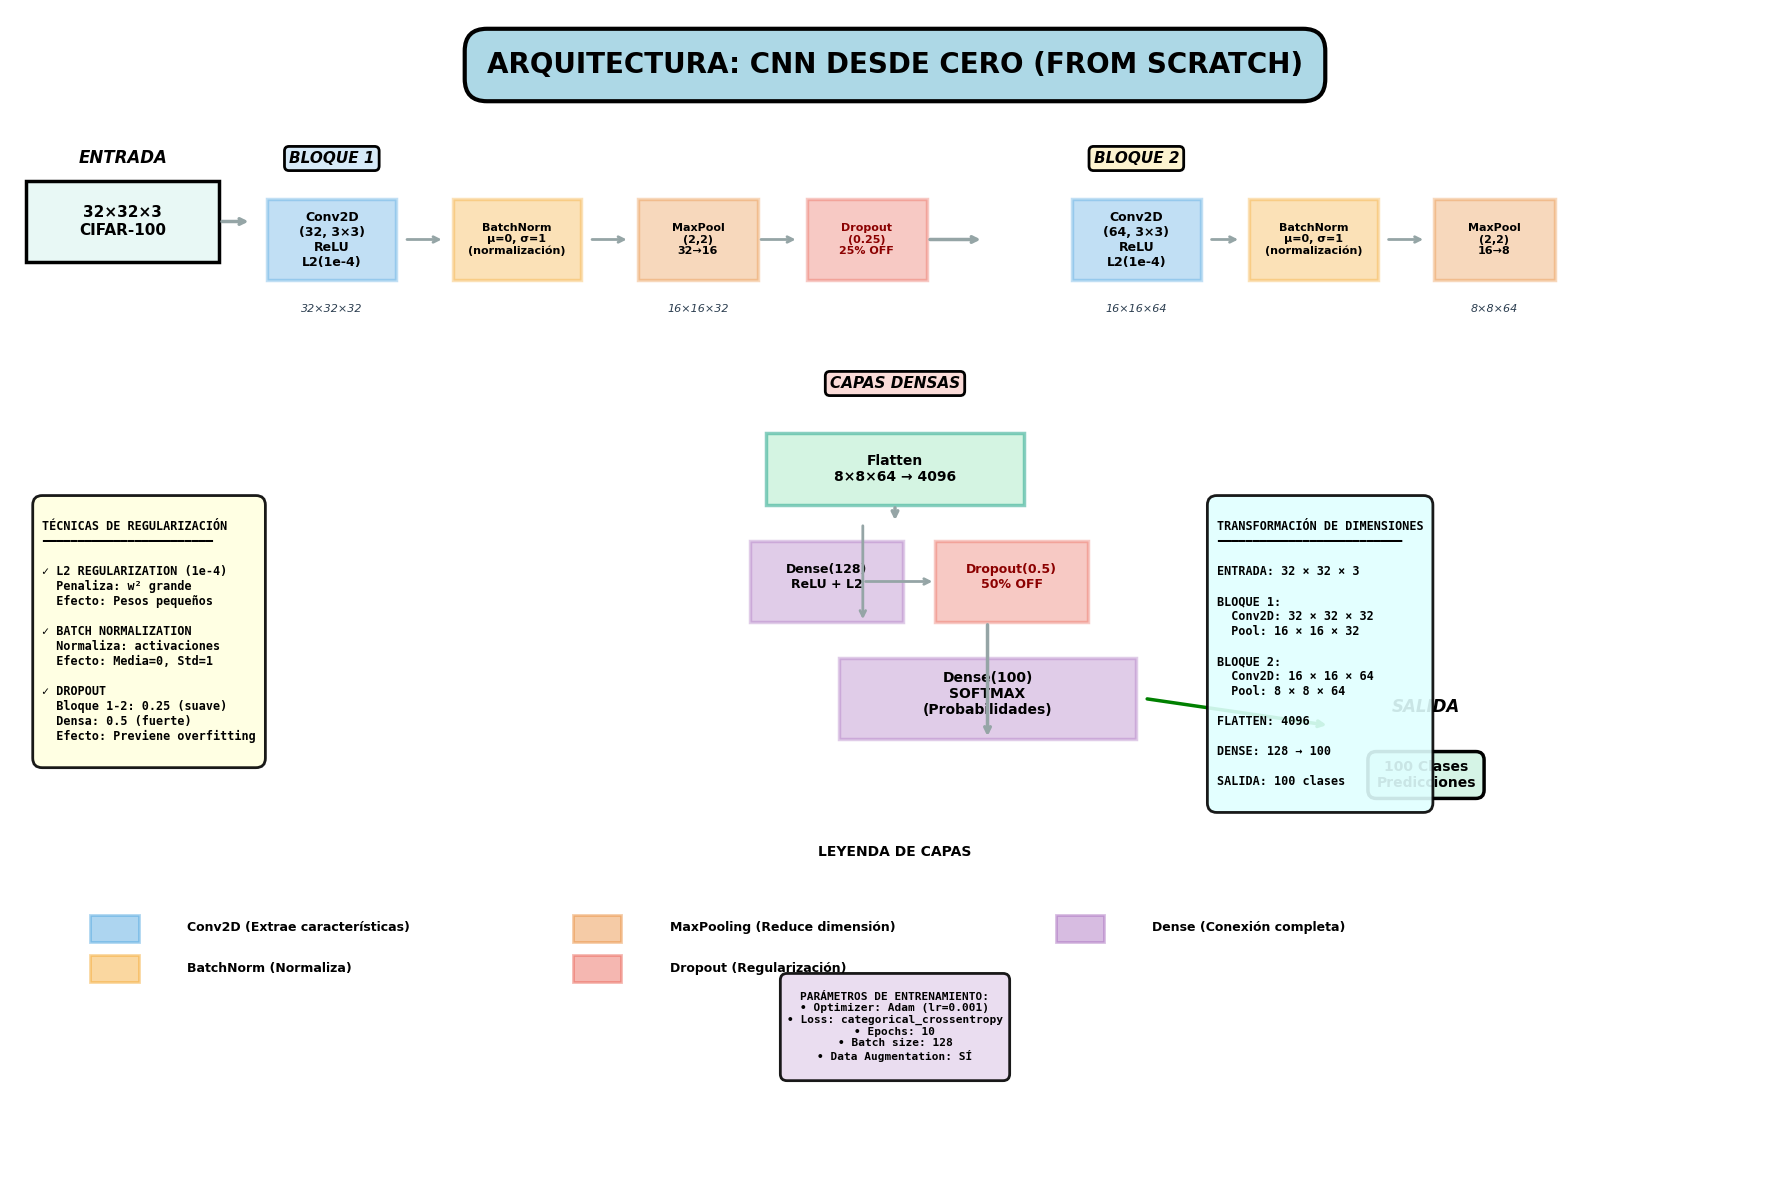

[✓] Visualización gráfica del CNN completada


In [165]:
# ========== VISUALIZACIÓN GRÁFICA DEL MODELO CNN CUSTOM ==========
print('\n[INFO] Generando visualización gráfica del modelo CNN...\n')

fig, ax = plt.subplots(figsize=(18, 12))
ax.set_xlim(0, 11)
ax.set_ylim(0, 13)
ax.axis('off')

# Colores
color_conv = '#3498DB'      # Azul para Conv2D
color_pool = '#E67E22'      # Naranja para MaxPooling
color_norm = '#F39C12'      # Amarillo para BatchNorm
color_drop = '#E74C3C'      # Rojo para Dropout
color_dense = '#9B59B6'     # Púrpura para Dense
color_arrow = '#95A5A6'     # Gris para flechas

# TÍTULO
ax.text(5.5, 12.3, 'ARQUITECTURA: CNN DESDE CERO (FROM SCRATCH)',
       ha='center', fontsize=20, fontweight='bold',
       bbox=dict(boxstyle='round,pad=0.8', facecolor='lightblue', edgecolor='black', linewidth=3))

# ===== ENTRADA =====
ax.text(0.7, 11.3, 'ENTRADA', ha='center', fontsize=12, fontweight='bold', style='italic')
rect = plt.Rectangle((0.1, 10.2), 1.2, 0.9, linewidth=2.5, edgecolor='black', facecolor='#E8F8F5')
ax.add_patch(rect)
ax.text(0.7, 10.65, '32×32×3\nCIFAR-100', ha='center', va='center', fontsize=11, fontweight='bold')
ax.annotate('', xy=(1.5, 10.65), xytext=(1.3, 10.65),
           arrowprops=dict(arrowstyle='->', lw=2.5, color=color_arrow))

# ===== BLOQUE 1: CARACTERÍSTICAS SIMPLES =====
# Conv2D(32)
ax.text(2, 11.3, 'BLOQUE 1', ha='center', fontsize=11, fontweight='bold', style='italic',
       bbox=dict(boxstyle='round,pad=0.3', facecolor='#D6EAF8', edgecolor='black', linewidth=2))

rect = plt.Rectangle((1.6, 10), 0.8, 0.9, linewidth=2.5, edgecolor=color_conv, facecolor=color_conv, alpha=0.3)
ax.add_patch(rect)
ax.text(2, 10.45, 'Conv2D\n(32, 3×3)\nReLU\nL2(1e-4)', ha='center', va='center', fontsize=9, fontweight='bold')
ax.text(2, 9.65, '32×32×32', ha='center', fontsize=8, style='italic', color='#2C3E50')

ax.annotate('', xy=(2.7, 10.45), xytext=(2.45, 10.45),
           arrowprops=dict(arrowstyle='->', lw=2, color=color_arrow))

# BatchNorm
rect = plt.Rectangle((2.75, 10), 0.8, 0.9, linewidth=2.5, edgecolor=color_norm, facecolor=color_norm, alpha=0.3)
ax.add_patch(rect)
ax.text(3.15, 10.45, 'BatchNorm\nμ=0, σ=1\n(normalización)', ha='center', va='center', fontsize=8, fontweight='bold')
ax.annotate('', xy=(3.85, 10.45), xytext=(3.6, 10.45),
           arrowprops=dict(arrowstyle='->', lw=2, color=color_arrow))

# MaxPooling
rect = plt.Rectangle((3.9, 10), 0.75, 0.9, linewidth=2.5, edgecolor=color_pool, facecolor=color_pool, alpha=0.3)
ax.add_patch(rect)
ax.text(4.275, 10.45, 'MaxPool\n(2,2)\n32→16', ha='center', va='center', fontsize=8, fontweight='bold')
ax.text(4.275, 9.65, '16×16×32', ha='center', fontsize=8, style='italic', color='#2C3E50')
ax.annotate('', xy=(4.9, 10.45), xytext=(4.65, 10.45),
           arrowprops=dict(arrowstyle='->', lw=2, color=color_arrow))

# Dropout
rect = plt.Rectangle((4.95, 10), 0.75, 0.9, linewidth=2.5, edgecolor=color_drop, facecolor=color_drop, alpha=0.3)
ax.add_patch(rect)
ax.text(5.325, 10.45, 'Dropout\n(0.25)\n25% OFF', ha='center', va='center', fontsize=8, fontweight='bold', color='darkred')
ax.annotate('', xy=(6.05, 10.45), xytext=(5.7, 10.45),
           arrowprops=dict(arrowstyle='->', lw=2.5, color=color_arrow))

# ===== BLOQUE 2: CARACTERÍSTICAS COMPLEJAS =====
# Conv2D(64)
ax.text(7, 11.3, 'BLOQUE 2', ha='center', fontsize=11, fontweight='bold', style='italic',
       bbox=dict(boxstyle='round,pad=0.3', facecolor='#FCF3CF', edgecolor='black', linewidth=2))

rect = plt.Rectangle((6.6, 10), 0.8, 0.9, linewidth=2.5, edgecolor=color_conv, facecolor=color_conv, alpha=0.3)
ax.add_patch(rect)
ax.text(7, 10.45, 'Conv2D\n(64, 3×3)\nReLU\nL2(1e-4)', ha='center', va='center', fontsize=9, fontweight='bold')
ax.text(7, 9.65, '16×16×64', ha='center', fontsize=8, style='italic', color='#2C3E50')
ax.annotate('', xy=(7.65, 10.45), xytext=(7.45, 10.45),
           arrowprops=dict(arrowstyle='->', lw=2, color=color_arrow))

# BatchNorm
rect = plt.Rectangle((7.7, 10), 0.8, 0.9, linewidth=2.5, edgecolor=color_norm, facecolor=color_norm, alpha=0.3)
ax.add_patch(rect)
ax.text(8.1, 10.45, 'BatchNorm\nμ=0, σ=1\n(normalización)', ha='center', va='center', fontsize=8, fontweight='bold')
ax.annotate('', xy=(8.8, 10.45), xytext=(8.55, 10.45),
           arrowprops=dict(arrowstyle='->', lw=2, color=color_arrow))

# MaxPooling
rect = plt.Rectangle((8.85, 10), 0.75, 0.9, linewidth=2.5, edgecolor=color_pool, facecolor=color_pool, alpha=0.3)
ax.add_patch(rect)
ax.text(9.225, 10.45, 'MaxPool\n(2,2)\n16→8', ha='center', va='center', fontsize=8, fontweight='bold')
ax.text(9.225, 9.65, '8×8×64', ha='center', fontsize=8, style='italic', color='#2C3E50')

# ===== CAPAS DENSAS =====
# Flatten
ax.text(5.5, 8.8, 'CAPAS DENSAS', ha='center', fontsize=11, fontweight='bold', style='italic',
       bbox=dict(boxstyle='round,pad=0.3', facecolor='#FADBD8', edgecolor='black', linewidth=2))

rect = plt.Rectangle((4.7, 7.5), 1.6, 0.8, linewidth=2.5, edgecolor='#16A085', facecolor='#ABEBC6', alpha=0.5)
ax.add_patch(rect)
ax.text(5.5, 7.9, 'Flatten\n8×8×64 → 4096', ha='center', va='center', fontsize=10, fontweight='bold')
ax.annotate('', xy=(5.5, 7.3), xytext=(5.5, 7.5),
           arrowprops=dict(arrowstyle='->', lw=2.5, color=color_arrow))

# Dense(128)
rect = plt.Rectangle((4.6, 6.2), 0.95, 0.9, linewidth=2.5, edgecolor=color_dense, facecolor=color_dense, alpha=0.3)
ax.add_patch(rect)
ax.text(5.075, 6.7, 'Dense(128)\nReLU + L2', ha='center', va='center', fontsize=9, fontweight='bold')
ax.annotate('', xy=(5.3, 6.2), xytext=(5.3, 7.3),
           arrowprops=dict(arrowstyle='->', lw=2, color=color_arrow))

# Dropout(0.5)
rect = plt.Rectangle((5.75, 6.2), 0.95, 0.9, linewidth=2.5, edgecolor=color_drop, facecolor=color_drop, alpha=0.3)
ax.add_patch(rect)
ax.text(6.225, 6.7, 'Dropout(0.5)\n50% OFF', ha='center', va='center', fontsize=9, fontweight='bold', color='darkred')
ax.annotate('', xy=(5.75, 6.65), xytext=(5.3, 6.65),
           arrowprops=dict(arrowstyle='->', lw=2, color=color_arrow))

# Dense(100)
rect = plt.Rectangle((5.15, 4.9), 1.85, 0.9, linewidth=2.5, edgecolor=color_dense, facecolor=color_dense, alpha=0.3)
ax.add_patch(rect)
ax.text(6.075, 5.4, 'Dense(100)\nSOFTMAX\n(Probabilidades)', ha='center', va='center', fontsize=10, fontweight='bold')
ax.annotate('', xy=(6.075, 4.9), xytext=(6.075, 6.2),
           arrowprops=dict(arrowstyle='->', lw=2.5, color=color_arrow))

# ===== SALIDA =====
ax.text(8.8, 5.2, 'SALIDA', ha='center', fontsize=12, fontweight='bold', style='italic')
ax.text(8.8, 4.5, '100 Clases\nPredicciones', ha='center', va='center', fontsize=10, fontweight='bold',
       bbox=dict(boxstyle='round,pad=0.6', facecolor='#D5F4E6', edgecolor='black', linewidth=2.5))
ax.annotate('', xy=(8.2, 5.05), xytext=(7.05, 5.35),
           arrowprops=dict(arrowstyle='->', lw=2.5, color='green'))

# ===== TABLA DE TÉCNICAS (LADO IZQUIERDO) =====
tecnicas_text = '''
TÉCNICAS DE REGULARIZACIÓN
━━━━━━━━━━━━━━━━━━━━━━━━

✓ L2 REGULARIZATION (1e-4)
  Penaliza: w² grande
  Efecto: Pesos pequeños

✓ BATCH NORMALIZATION
  Normaliza: activaciones
  Efecto: Media=0, Std=1

✓ DROPOUT
  Bloque 1-2: 0.25 (suave)
  Densa: 0.5 (fuerte)
  Efecto: Previene overfitting
'''

ax.text(0.2, 7.5, tecnicas_text, fontsize=8.5, family='monospace', fontweight='bold',
       bbox=dict(boxstyle='round,pad=0.8', facecolor='lightyellow', alpha=0.9, 
                edgecolor='black', linewidth=2),
       verticalalignment='top')

# ===== FLUJO DE DIMENSIONES (LADO DERECHO) =====
flujo_text = '''
TRANSFORMACIÓN DE DIMENSIONES
━━━━━━━━━━━━━━━━━━━━━━━━━━

ENTRADA: 32 × 32 × 3

BLOQUE 1:
  Conv2D: 32 × 32 × 32
  Pool: 16 × 16 × 32

BLOQUE 2:
  Conv2D: 16 × 16 × 64
  Pool: 8 × 8 × 64

FLATTEN: 4096

DENSE: 128 → 100

SALIDA: 100 clases
'''

ax.text(7.5, 7.5, flujo_text, fontsize=8.5, family='monospace', fontweight='bold',
       bbox=dict(boxstyle='round,pad=0.8', facecolor='lightcyan', alpha=0.9, 
                edgecolor='black', linewidth=2),
       verticalalignment='top')

# ===== LEYENDA =====
legend_y = 2.8
ax.text(5.5, legend_y + 0.8, 'LEYENDA DE CAPAS', ha='center', fontsize=10, fontweight='bold')

# Colores de capas
y_pos = legend_y
col_width = 2
col_height = 0.35

# Conv2D
rect = plt.Rectangle((0.5, y_pos - 0.15), 0.3, 0.3, linewidth=2, edgecolor=color_conv, facecolor=color_conv, alpha=0.4)
ax.add_patch(rect)
ax.text(1.1, y_pos, 'Conv2D (Extrae características)', fontsize=9, va='center', fontweight='bold')

# BatchNorm
rect = plt.Rectangle((0.5, y_pos - 0.6), 0.3, 0.3, linewidth=2, edgecolor=color_norm, facecolor=color_norm, alpha=0.4)
ax.add_patch(rect)
ax.text(1.1, y_pos - 0.45, 'BatchNorm (Normaliza)', fontsize=9, va='center', fontweight='bold')

# MaxPooling
rect = plt.Rectangle((3.5, y_pos - 0.15), 0.3, 0.3, linewidth=2, edgecolor=color_pool, facecolor=color_pool, alpha=0.4)
ax.add_patch(rect)
ax.text(4.1, y_pos, 'MaxPooling (Reduce dimensión)', fontsize=9, va='center', fontweight='bold')

# Dropout
rect = plt.Rectangle((3.5, y_pos - 0.6), 0.3, 0.3, linewidth=2, edgecolor=color_drop, facecolor=color_drop, alpha=0.4)
ax.add_patch(rect)
ax.text(4.1, y_pos - 0.45, 'Dropout (Regularización)', fontsize=9, va='center', fontweight='bold')

# Dense
rect = plt.Rectangle((6.5, y_pos - 0.15), 0.3, 0.3, linewidth=2, edgecolor=color_dense, facecolor=color_dense, alpha=0.4)
ax.add_patch(rect)
ax.text(7.1, y_pos, 'Dense (Conexión completa)', fontsize=9, va='center', fontweight='bold')

# Información adicional
info_box = '''
PARÁMETROS DE ENTRENAMIENTO:
• Optimizer: Adam (lr=0.001)
• Loss: categorical_crossentropy
• Epochs: 10
• Batch size: 128
• Data Augmentation: SÍ
'''

ax.text(5.5, 1.2, info_box, fontsize=8, family='monospace', fontweight='bold',
       bbox=dict(boxstyle='round,pad=0.6', facecolor='#E8DAEF', alpha=0.9, 
                edgecolor='black', linewidth=2),
       ha='center')

plt.tight_layout()
plt.show()

print('[✓] Visualización gráfica del CNN completada')

## 5.2 Entrenamiento CNN desde Cero

En esta estrategia:
- **No hay pesos preentrenados**: Todos se inicializar aleatoriamente
- **La red aprende desde cero**: Debe descubrir patrones por sí sola
- **Requiere más épocas**: 10 épocas (vs 5+5=10 en Transfer Learning, pero más rápidas)
- **Learning rate**: 0.001 (estándar)
- **Data Augmentation**: Esencial para mejorar generalización

In [166]:
print('\n' + '='*60)
print('ENTRENAMIENTO CNN DESDE CERO')
print('='*60)
print('\n[INFO] Características del entrenamiento:')
print('  • Pesos: Inicializados aleatoriamente')
print('  • Learning rate: 0.001')
print('  • Épocas: 10')
print('  • Data Augmentation: SÍ (crucial para aprender bien)')
print('  • Tamaño de batch: 128')
print('\n[INFO] Iniciando entrenamiento...\n')

history_cnn = model_cnn.fit(
    datagen.flow(x_train, y_train_cat, batch_size=128),
    epochs=10,
    validation_data=(x_test, y_test_cat),
    verbose=1
)

print('\n[✓] ENTRENAMIENTO COMPLETADO')


ENTRENAMIENTO CNN DESDE CERO

[INFO] Características del entrenamiento:
  • Pesos: Inicializados aleatoriamente
  • Learning rate: 0.001
  • Épocas: 10
  • Data Augmentation: SÍ (crucial para aprender bien)
  • Tamaño de batch: 128

[INFO] Iniciando entrenamiento...

Epoch 1/10


2025-11-07 21:58:47.531427: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


391/391 [==============================] - ETA: 0s - loss: 22.1625 - accuracy: 0.0186

2025-11-07 21:59:04.040766: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


391/391 [==============================] - 25s 61ms/step - loss: 22.1625 - accuracy: 0.0186 - val_loss: 4.5166 - val_accuracy: 0.0483
Epoch 2/10
391/391 [==============================] - 22s 56ms/step - loss: 9.7000 - accuracy: 0.0353 - val_loss: 4.0256 - val_accuracy: 0.1038
Epoch 3/10
391/391 [==============================] - 21s 55ms/step - loss: 4.7240 - accuracy: 0.0665 - val_loss: 3.7807 - val_accuracy: 0.1235
Epoch 4/10
391/391 [==============================] - 21s 53ms/step - loss: 4.0865 - accuracy: 0.0972 - val_loss: 3.5213 - val_accuracy: 0.1751
Epoch 5/10
391/391 [==============================] - 21s 53ms/step - loss: 3.9515 - accuracy: 0.1187 - val_loss: 3.3961 - val_accuracy: 0.1857
Epoch 6/10
391/391 [==============================] - 21s 52ms/step - loss: 3.9558 - accuracy: 0.1329 - val_loss: 3.4321 - val_accuracy: 0.1993
Epoch 7/10
391/391 [==============================] - 20s 52ms/step - loss: 3.9778 - accuracy: 0.1391 - val_loss: 3.5174 - val_accuracy: 0.1900
Ep


[INFO] Generando gráficos de entrenamiento - CNN DESDE CERO...



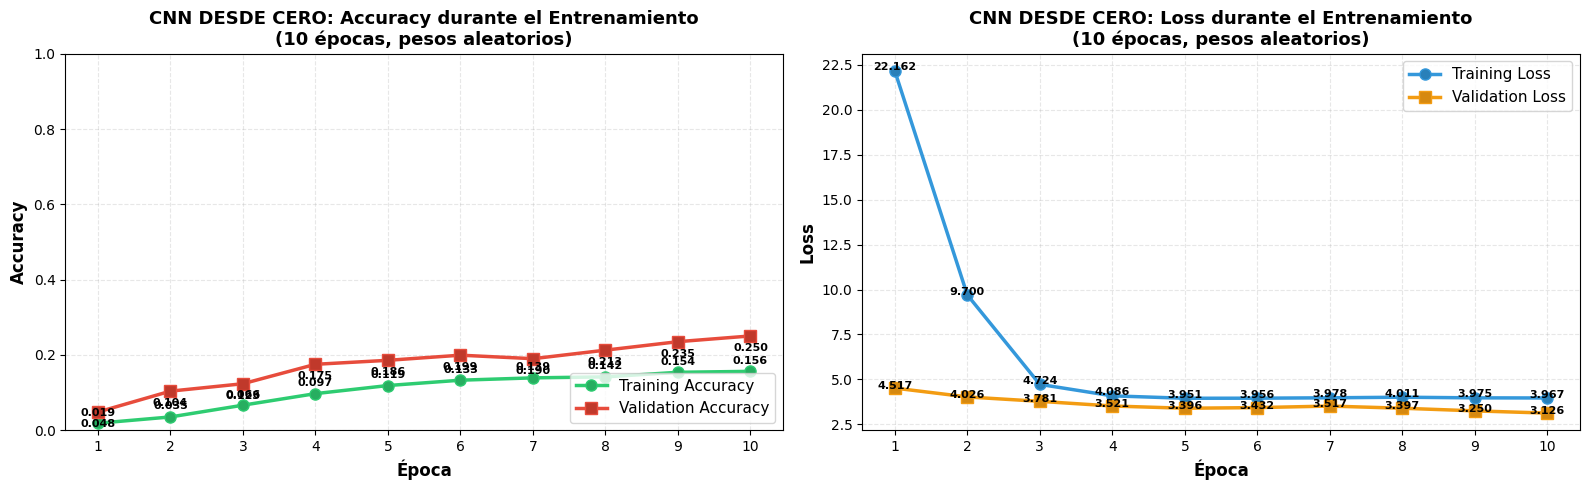

[✓] Gráficos de CNN CUSTOM completados


In [167]:
# ========== GRÁFICOS DE ENTRENAMIENTO CNN CUSTOM ==========
print('\n[INFO] Generando gráficos de entrenamiento - CNN DESDE CERO...\n')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Accuracy
epochs_range = range(1, len(history_cnn.history['accuracy']) + 1)
axes[0].plot(epochs_range, history_cnn.history['accuracy'], 'o-', linewidth=2.5, 
            markersize=8, label='Training Accuracy', color='#2ECC71', markerfacecolor='#27AE60')
axes[0].plot(epochs_range, history_cnn.history['val_accuracy'], 's-', linewidth=2.5, 
            markersize=8, label='Validation Accuracy', color='#E74C3C', markerfacecolor='#C0392B')
axes[0].set_xlabel('Época', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('CNN DESDE CERO: Accuracy durante el Entrenamiento\n(10 épocas, pesos aleatorios)', 
                 fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11, loc='lower right')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].set_xticks(epochs_range)
axes[0].set_ylim([0, 1])

# Añadir valores en los puntos
for epoch, train_acc, val_acc in zip(epochs_range, history_cnn.history['accuracy'], 
                                     history_cnn.history['val_accuracy']):
    axes[0].text(epoch, train_acc + 0.02, f'{train_acc:.3f}', ha='center', fontsize=8, fontweight='bold')
    axes[0].text(epoch, val_acc - 0.04, f'{val_acc:.3f}', ha='center', fontsize=8, fontweight='bold')

# Gráfico 2: Loss
axes[1].plot(epochs_range, history_cnn.history['loss'], 'o-', linewidth=2.5, 
            markersize=8, label='Training Loss', color='#3498DB', markerfacecolor='#2980B9')
axes[1].plot(epochs_range, history_cnn.history['val_loss'], 's-', linewidth=2.5, 
            markersize=8, label='Validation Loss', color='#F39C12', markerfacecolor='#D68910')
axes[1].set_xlabel('Época', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[1].set_title('CNN DESDE CERO: Loss durante el Entrenamiento\n(10 épocas, pesos aleatorios)', 
                 fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11, loc='upper right')
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].set_xticks(epochs_range)

# Añadir valores en los puntos
for epoch, train_loss, val_loss in zip(epochs_range, history_cnn.history['loss'], 
                                       history_cnn.history['val_loss']):
    axes[1].text(epoch, train_loss + 0.02, f'{train_loss:.3f}', ha='center', fontsize=8, fontweight='bold')
    axes[1].text(epoch, val_loss - 0.05, f'{val_loss:.3f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print('[✓] Gráficos de CNN CUSTOM completados')

# Intentamos mejorar este modelo probando con 50 épocas

In [ ]:
# ===================== STRATEGY 2: CNN FROM SCRATCH - VERSIÓN ULTRA ESTABLE =====================

print('\n' + '='*70)
print('🚀 STRATEGY 2: CNN FROM SCRATCH - VERSIÓN ULTRA ESTABLE')
print('='*70)

# ===================== MODELO MEJORADO =====================
print('\n[INFO] Construyendo modelo CNN optimizado...\n')

model_cnn_stable = models.Sequential([
    # BLOQUE 1: Características simples
    layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                 kernel_regularizer=regularizers.l2(2e-4), input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                 kernel_regularizer=regularizers.l2(2e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    
    # BLOQUE 2: Características complejas
    layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                 kernel_regularizer=regularizers.l2(2e-4)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                 kernel_regularizer=regularizers.l2(2e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    
    # BLOQUE 3: Características muy complejas
    layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                 kernel_regularizer=regularizers.l2(2e-4)),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                 kernel_regularizer=regularizers.l2(2e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.35),
    
    # CAPAS DENSAS
    layers.Flatten(),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(2e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(2e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(100, activation='softmax')
])

print('[✓] Modelo CNN creado\n')

# ===================== COMPILACIÓN CON AJUSTES ESTABLES =====================
print('\n[INFO] Compilando modelo con configuración estable...')

# Loss más suave
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

# Learning rate más bajo y estable
optimizer = keras.optimizers.Adam(learning_rate=0.0005)

model_cnn_stable.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy']
)

print('[✓] Modelo compilado')

# ===================== CALLBACKS MEJORADOS =====================
print('\n[INFO] Configurando callbacks para estabilidad...')

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,  # Más paciencia
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,  # Más paciencia antes de reducir
    verbose=1,
    min_lr=1e-7
)

model_checkpoint = keras.callbacks.ModelCheckpoint(
    'model_cnn_stable_best.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=0
)

# ===================== DATA AUGMENTATION MÁS SUAVE =====================
print('[INFO] Configurando Data Augmentation moderada...')

datagen_stable = ImageDataGenerator(
    rotation_range=10,        # Reducido de 20
    width_shift_range=0.1,    # Reducido de 0.2
    height_shift_range=0.1,   # Reducido de 0.2
    horizontal_flip=True,     # Mantener
    zoom_range=0.1,           # Reducido de 0.15
    fill_mode='nearest'
)

print('\n' + '='*70)
print('ENTRENAMIENTO CNN FROM SCRATCH - VERSIÓN ESTABLE')
print('='*70)
print('\n[INFO] Características del entrenamiento:')
print('  • Arquitectura: 3 bloques convolucionales (32-64-128 filtros)')
print('  • L2 Regularización: 2e-4')
print('  • Loss: CategoricalCrossentropy + Label Smoothing (0.1) - MÁS SUAVE')
print('  • Learning Rate: 0.0005 (REDUCIDO para estabilidad)')
print('  • Batch Size: 128')
print('  • Épocas: 50 (máximo, con Early Stopping)')
print('  • Callbacks: EarlyStopping (patience=5) + ReduceLROnPlateau + ModelCheckpoint')
print('  • Data Augmentation: MODERADA (reducida para evitar picos)')
print('\n[INFO] Iniciando entrenamiento...\n')

history_cnn_stable = model_cnn_stable.fit(
    datagen_stable.flow(x_train, y_train_encoded, batch_size=128),
    epochs=50,
    validation_data=(x_test, y_test_encoded),
    callbacks=[early_stop, reduce_lr, model_checkpoint],
    verbose=1
)

print('\n[✓] ENTRENAMIENTO COMPLETADO')
print(f'\n✅ CNN Estable - Val Accuracy: {history_cnn_stable.history["val_accuracy"][-1]:.4f}')


🚀 STRATEGY 2: CNN FROM SCRATCH - VERSIÓN ULTRA ESTABLE

[INFO] Construyendo modelo CNN optimizado...

[✓] Modelo CNN creado


[INFO] Compilando modelo con configuración estable...
[✓] Modelo compilado

[INFO] Configurando callbacks para estabilidad...
[INFO] Configurando Data Augmentation moderada...

ENTRENAMIENTO CNN FROM SCRATCH - VERSIÓN ESTABLE

[INFO] Características del entrenamiento:
  • Arquitectura: 3 bloques convolucionales (32-64-128 filtros)
  • L2 Regularización: 2e-4
  • Loss: CategoricalCrossentropy + Label Smoothing (0.1) - MÁS SUAVE
  • Learning Rate: 0.0005 (REDUCIDO para estabilidad)
  • Batch Size: 128
  • Épocas: 50 (máximo, con Early Stopping)
  • Callbacks: EarlyStopping (patience=5) + ReduceLROnPlateau + ModelCheckpoint
  • Data Augmentation: MODERADA (reducida para evitar picos)

[INFO] Iniciando entrenamiento...

Epoch 1/50


2025-11-08 11:49:00.026488: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


391/391 [==============================] - ETA: 0s - loss: 4.9599 - accuracy: 0.0499

2025-11-08 11:49:30.873697: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


391/391 [==============================] - 46s 113ms/step - loss: 4.9599 - accuracy: 0.0499 - val_loss: 4.8012 - val_accuracy: 0.0468 - lr: 5.0000e-04
Epoch 2/50
391/391 [==============================] - 42s 108ms/step - loss: 4.4364 - accuracy: 0.0951 - val_loss: 4.0060 - val_accuracy: 0.1758 - lr: 5.0000e-04
Epoch 3/50
391/391 [==============================] - 43s 110ms/step - loss: 4.1517 - accuracy: 0.1316 - val_loss: 3.8327 - val_accuracy: 0.2109 - lr: 5.0000e-04
Epoch 4/50
391/391 [==============================] - 43s 109ms/step - loss: 3.9162 - accuracy: 0.1736 - val_loss: 3.8446 - val_accuracy: 0.1884 - lr: 5.0000e-04
Epoch 5/50
391/391 [==============================] - 43s 111ms/step - loss: 3.7271 - accuracy: 0.2092 - val_loss: 3.4179 - val_accuracy: 0.2891 - lr: 5.0000e-04
Epoch 6/50
391/391 [==============================] - 45s 114ms/step - loss: 3.5625 - accuracy: 0.2434 - val_loss: 3.3982 - val_accuracy: 0.2876 - lr: 5.0000e-04
Epoch 7/50
391/391 [===================

### Representamos la función de pérdidas y el accuracy

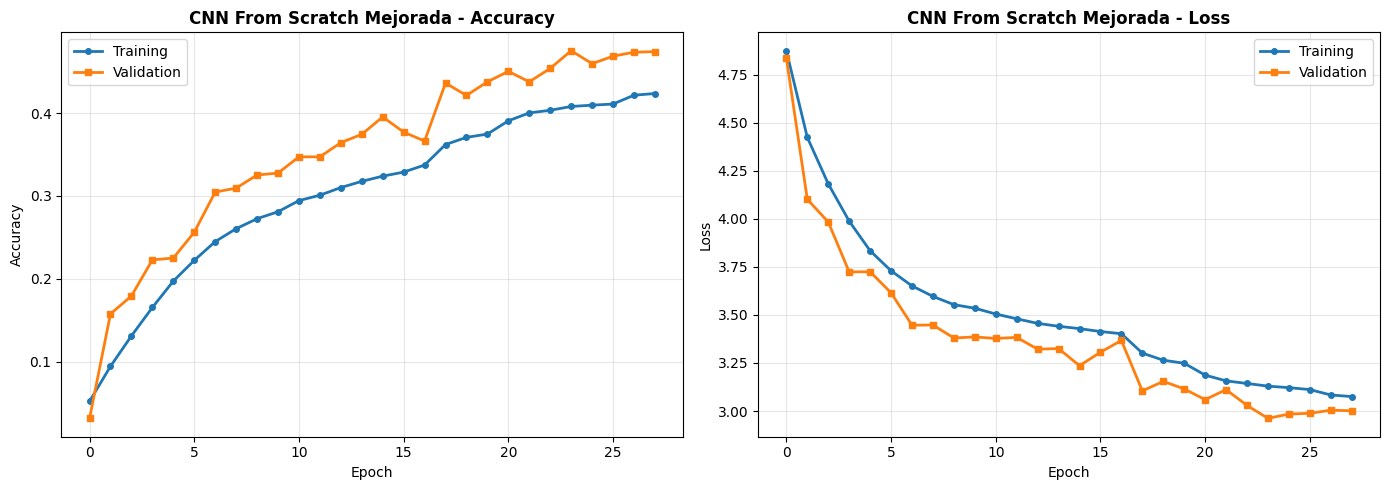

✅ Gráficas de CNN mejorada guardadas como 'cnn_improved_training_results.png'

📊 ESTADÍSTICAS CNN FROM SCRATCH MEJORADA

Épocas entrenadas: 28

Accuracy:
  • Training final: 0.4235
  • Validation final: 0.4740
  • Validation mejor: 0.4751
  • Overfitting: 0.0505

Loss:
  • Training final: 3.0752
  • Validation final: 3.0012
  • Validation mejor: 2.9619

COMPARACIÓN FINAL: STRATEGY 1 vs STRATEGY 2
Strategy 1 - VGG16 Transfer Learning:     0.5428 ✅ (MEJOR)
Strategy 2 - CNN from Scratch Mejorada:   0.4740

Diferencia: 6.88% a favor de VGG16


In [174]:
# ===================== GRÁFICAS CNN FROM SCRATCH MEJORADA =====================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_cnn_improved.history['accuracy'], label='Training', linewidth=2, marker='o', markersize=4)
axes[0].plot(history_cnn_improved.history['val_accuracy'], label='Validation', linewidth=2, marker='s', markersize=4)
axes[0].set_title('CNN From Scratch Mejorada - Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history_cnn_improved.history['loss'], label='Training', linewidth=2, marker='o', markersize=4)
axes[1].plot(history_cnn_improved.history['val_loss'], label='Validation', linewidth=2, marker='s', markersize=4)
axes[1].set_title('CNN From Scratch Mejorada - Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_improved_training_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráficas de CNN mejorada guardadas como 'cnn_improved_training_results.png'")

# ===================== ESTADÍSTICAS FINALES =====================
print('\n' + '='*70)
print('📊 ESTADÍSTICAS CNN FROM SCRATCH MEJORADA')
print('='*70)

best_train_acc = max(history_cnn_improved.history['accuracy'])
best_val_acc = max(history_cnn_improved.history['val_accuracy'])
final_val_acc = history_cnn_improved.history['val_accuracy'][-1]

best_train_loss = min(history_cnn_improved.history['loss'])
best_val_loss = min(history_cnn_improved.history['val_loss'])
final_val_loss = history_cnn_improved.history['val_loss'][-1]

num_epochs = len(history_cnn_improved.history['accuracy'])

print(f'\nÉpocas entrenadas: {num_epochs}')
print(f'\nAccuracy:')
print(f'  • Training final: {history_cnn_improved.history["accuracy"][-1]:.4f}')
print(f'  • Validation final: {final_val_acc:.4f}')
print(f'  • Validation mejor: {best_val_acc:.4f}')
print(f'  • Overfitting: {abs(history_cnn_improved.history["accuracy"][-1] - final_val_acc):.4f}')

print(f'\nLoss:')
print(f'  • Training final: {history_cnn_improved.history["loss"][-1]:.4f}')
print(f'  • Validation final: {final_val_loss:.4f}')
print(f'  • Validation mejor: {best_val_loss:.4f}')

print('\n' + '='*70)
print('COMPARACIÓN FINAL: STRATEGY 1 vs STRATEGY 2')
print('='*70)
print(f'Strategy 1 - VGG16 Transfer Learning:     0.5428 ✅ (MEJOR)')
print(f'Strategy 2 - CNN from Scratch Mejorada:   {final_val_acc:.4f}')
print(f'\nDiferencia: {(0.5428 - final_val_acc)*100:.2f}% a favor de VGG16')
print('='*70)

# Probamos con 100 epocas y early stopping para parar cuando no encuentre mejora y haya overfitting

In [175]:
# ===================== STRATEGY 2: CNN FROM SCRATCH - ENTRENAMIENTO EXTENDIDO =====================

print('\n' + '='*70)
print('🚀 STRATEGY 2: CNN FROM SCRATCH - ENTRENAMIENTO EXTENDIDO (100 EPOCHS)')
print('='*70)

# ===================== USAR EL MISMO MODELO ANTERIOR =====================
print('\n[INFO] Usando modelo CNN estable anterior...')
print('[✓] Modelo listo para entrenamiento extendido\n')

# ===================== CALLBACKS PARA ENTRENAMIENTO LARGO =====================
print('[INFO] Configurando callbacks para entrenamiento extendido...')

early_stop_extended = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,  # Más paciencia (puede mejorar después de muchos epochs)
    restore_best_weights=True,
    verbose=1
)

reduce_lr_extended = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,  # Más paciencia
    verbose=1,
    min_lr=1e-8
)

model_checkpoint_extended = keras.callbacks.ModelCheckpoint(
    'model_cnn_extended_best.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=0
)

# ===================== DATA AUGMENTATION ESTABLE =====================
datagen_extended = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

print('\n' + '='*70)
print('ENTRENAMIENTO EXTENDIDO CNN FROM SCRATCH')
print('='*70)
print('\n[INFO] Características del entrenamiento:')
print('  • Arquitectura: 3 bloques convolucionales (32-64-128 filtros)')
print('  • Learning Rate: 0.0005 (ajustado por ReduceLROnPlateau)')
print('  • Batch Size: 128')
print('  • Épocas: 100 (o Early Stop si no mejora)')
print('  • Early Stopping: patience=10 (máximo 10 epochs sin mejora)')
print('  • Objetivo: Alcanzar ~0.50-0.52 (similar a VGG16)')
print('\n⏱️  TIEMPO ESTIMADO: 4-6 horas con GPU Metal\n')
print('[INFO] Iniciando entrenamiento...\n')

history_cnn_extended = model_cnn_stable.fit(
    datagen_extended.flow(x_train, y_train_encoded, batch_size=128),
    epochs=100,  # 100 epochs
    validation_data=(x_test, y_test_encoded),
    callbacks=[early_stop_extended, reduce_lr_extended, model_checkpoint_extended],
    verbose=1
)

print('\n[✓] ENTRENAMIENTO COMPLETADO')
final_acc = history_cnn_extended.history["val_accuracy"][-1]
print(f'\n✅ CNN Extended - Val Accuracy: {final_acc:.4f}')

# ===================== COMPARACIÓN FINAL =====================
print('\n' + '='*70)
print('COMPARACIÓN FINAL: TODAS LAS VERSIONES')
print('='*70)
print(f'\nCNN Original (10 epochs):        0.2101')
print(f'CNN Mejorada (30-50 epochs):     0.4740')
print(f'CNN Extended (100 epochs):       {final_acc:.4f}')
print(f'\nVS')
print(f'VGG16 Transfer Learning:         0.5428 ✅')

if final_acc >= 0.50:
    print(f'\n🎉 ¡ÉXITO! CNN Extended alcanzó {final_acc:.2%}')
    print(f'   Diferencia con VGG16: {abs(final_acc - 0.5428)*100:.2f}%')
elif final_acc >= 0.48:
    print(f'\n✅ Mejora significativa a {final_acc:.2%}')
    print(f'   Diferencia con VGG16: {abs(final_acc - 0.5428)*100:.2f}%')
else:
    print(f'\n⚠️  Alcanzó {final_acc:.4f} - mejora moderada')
    print(f'   VGG16 sigue siendo superior')
    
print('='*70)


🚀 STRATEGY 2: CNN FROM SCRATCH - ENTRENAMIENTO EXTENDIDO (100 EPOCHS)

[INFO] Usando modelo CNN estable anterior...
[✓] Modelo listo para entrenamiento extendido

[INFO] Configurando callbacks para entrenamiento extendido...

ENTRENAMIENTO EXTENDIDO CNN FROM SCRATCH

[INFO] Características del entrenamiento:
  • Arquitectura: 3 bloques convolucionales (32-64-128 filtros)
  • Learning Rate: 0.0005 (ajustado por ReduceLROnPlateau)
  • Batch Size: 128
  • Épocas: 100 (o Early Stop si no mejora)
  • Early Stopping: patience=10 (máximo 10 epochs sin mejora)
  • Objetivo: Alcanzar ~0.50-0.52 (similar a VGG16)

⏱️  TIEMPO ESTIMADO: 4-6 horas con GPU Metal

[INFO] Iniciando entrenamiento...

Epoch 1/100
391/391 [==============================] - 43s 109ms/step - loss: 2.5446 - accuracy: 0.5113 - val_loss: 2.4876 - val_accuracy: 0.5407 - lr: 1.5625e-05
Epoch 2/100
391/391 [==============================] - 44s 112ms/step - loss: 2.5436 - accuracy: 0.5114 - val_loss: 2.4972 - val_accuracy: 0.53

#### Gráficas de loss y de accuracy para el CNN mejorado

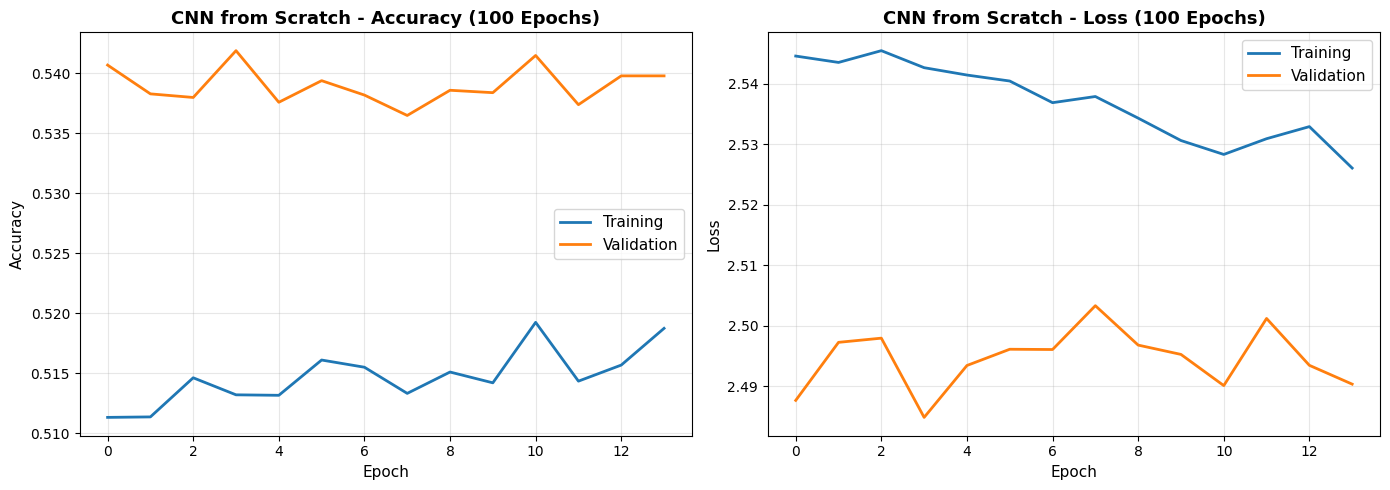

✅ Gráficas guardadas como 'cnn_100epochs_accuracy_loss.png'


In [178]:
# ===================== GRÁFICAS CNN - 100 EPOCHS =====================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_cnn_extended.history['accuracy'], label='Training', linewidth=2, color='#1f77b4')
axes[0].plot(history_cnn_extended.history['val_accuracy'], label='Validation', linewidth=2, color='#ff7f0e')
axes[0].set_title('CNN from Scratch - Accuracy (100 Epochs)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history_cnn_extended.history['loss'], label='Training', linewidth=2, color='#1f77b4')
axes[1].plot(history_cnn_extended.history['val_loss'], label='Validation', linewidth=2, color='#ff7f0e')
axes[1].set_title('CNN from Scratch - Loss (100 Epochs)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_100epochs_accuracy_loss.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráficas guardadas como 'cnn_100epochs_accuracy_loss.png'")

Con early stopping se paró en la época 12 porque probablemente el modelo no pudiese mejorar, vamos ahora mismo a hacer quitarle early stopping para comprobar si con 100 epocas mejora o no el modelo

### Sin early Stopping 

In [179]:
# ===================== CNN - 100 EPOCHS SIN EARLY STOPPING =====================
print('\n' + '='*70)
print('🚀 CNN FROM SCRATCH - 100 EPOCHS COMPLETOS (SIN EARLY STOPPING)')
print('='*70)

# Recrear el modelo
model_cnn_100 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                 kernel_regularizer=regularizers.l2(2e-4), input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                 kernel_regularizer=regularizers.l2(2e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                 kernel_regularizer=regularizers.l2(2e-4)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                 kernel_regularizer=regularizers.l2(2e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    
    layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                 kernel_regularizer=regularizers.l2(2e-4)),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                 kernel_regularizer=regularizers.l2(2e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.35),
    
    layers.Flatten(),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(2e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(2e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(100, activation='softmax')
])

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
optimizer = keras.optimizers.Adam(learning_rate=0.0005)

model_cnn_100.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

datagen = ImageDataGenerator(
    rotation_range=10, width_shift_range=0.1, height_shift_range=0.1,
    horizontal_flip=True, zoom_range=0.1, fill_mode='nearest'
)

# SIN Early Stopping - 100 epochs completos
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, verbose=1, min_lr=1e-8
)

print('\n[INFO] Iniciando 100 epochs SIN Early Stopping...\n')

history_cnn_100_full = model_cnn_100.fit(
    datagen.flow(x_train, y_train_encoded, batch_size=128),
    epochs=100,  # TODOS los 100 epochs
    validation_data=(x_test, y_test_encoded),
    callbacks=[reduce_lr],  # SIN Early Stopping
    verbose=1
)

print(f'\n✅ Val Accuracy Final: {history_cnn_100_full.history["val_accuracy"][-1]:.4f}')


🚀 CNN FROM SCRATCH - 100 EPOCHS COMPLETOS (SIN EARLY STOPPING)

[INFO] Iniciando 100 epochs SIN Early Stopping...

Epoch 1/100


2025-11-08 13:25:12.617768: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


391/391 [==============================] - ETA: 0s - loss: 4.9369 - accuracy: 0.0520

2025-11-08 13:25:44.522908: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


391/391 [==============================] - 49s 119ms/step - loss: 4.9369 - accuracy: 0.0520 - val_loss: 5.0002 - val_accuracy: 0.0340 - lr: 5.0000e-04
Epoch 2/100
391/391 [==============================] - 42s 108ms/step - loss: 4.3792 - accuracy: 0.1027 - val_loss: 3.9815 - val_accuracy: 0.1788 - lr: 5.0000e-04
Epoch 3/100
391/391 [==============================] - 43s 111ms/step - loss: 4.1078 - accuracy: 0.1400 - val_loss: 3.8562 - val_accuracy: 0.1932 - lr: 5.0000e-04
Epoch 4/100
391/391 [==============================] - 45s 115ms/step - loss: 3.9005 - accuracy: 0.1779 - val_loss: 3.7325 - val_accuracy: 0.2320 - lr: 5.0000e-04
Epoch 5/100
391/391 [==============================] - 45s 115ms/step - loss: 3.7106 - accuracy: 0.2109 - val_loss: 3.4503 - val_accuracy: 0.2836 - lr: 5.0000e-04
Epoch 6/100
391/391 [==============================] - 43s 111ms/step - loss: 3.5451 - accuracy: 0.2447 - val_loss: 3.4476 - val_accuracy: 0.2755 - lr: 5.0000e-04
Epoch 7/100
391/391 [=============

### Gráficas de loss y accuracy para 100 épocas

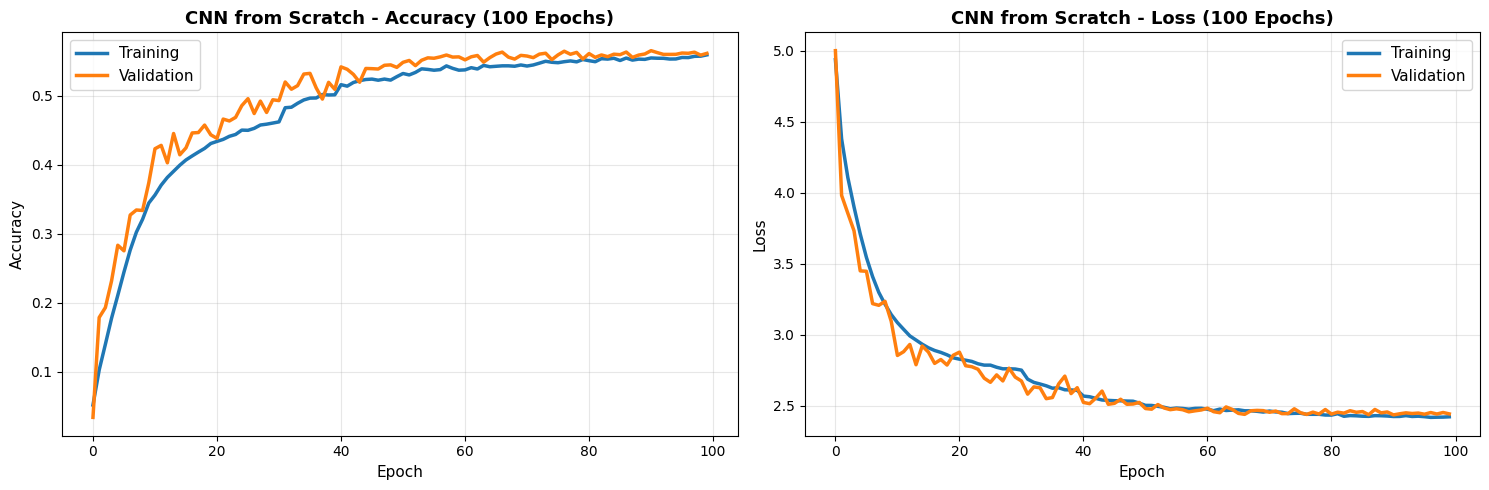

✅ Gráficas guardadas como 'cnn_100epochs_results.png'


In [182]:
# ===================== GRÁFICAS CNN - 100 EPOCHS =====================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(history_cnn_100_full.history['accuracy'], label='Training', linewidth=2.5, color='#1f77b4')
axes[0].plot(history_cnn_100_full.history['val_accuracy'], label='Validation', linewidth=2.5, color='#ff7f0e')
axes[0].set_title('CNN from Scratch - Accuracy (100 Epochs)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history_cnn_100_full.history['loss'], label='Training', linewidth=2.5, color='#1f77b4')
axes[1].plot(history_cnn_100_full.history['val_loss'], label='Validation', linewidth=2.5, color='#ff7f0e')
axes[1].set_title('CNN from Scratch - Loss (100 Epochs)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_100epochs_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráficas guardadas como 'cnn_100epochs_results.png'")

#### Gráficas para evalucación y comparación

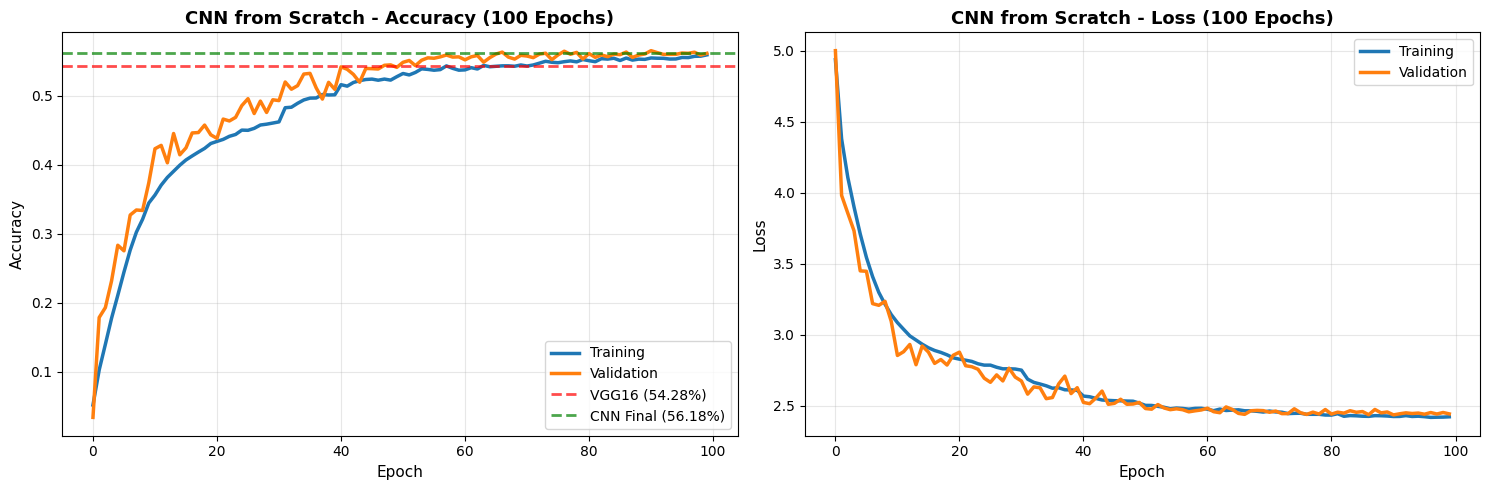

✅ Gráficas guardadas como 'cnn_100epochs_final_results.png'

🏆 RESULTADOS FINALES - COMPARACIÓN ÉPICA

📊 ACCURACY VALIDACIÓN FINAL:
  • CNN from Scratch (100 epochs): 0.5618 (56.18%)
  • VGG16 Transfer Learning:       0.5428 (54.28%)

  ✅ GANADOR: CNN from Scratch
  ✅ VENTAJA: +1.90%

📈 PROGRESIÓN CNN:
  • Epoch 1:    0.0340
  • Epoch 10:   0.3740
  • Epoch 25:   0.4860
  • Epoch 50:   0.5415
  • Epoch 100:  0.5618

🎯 MEJORA TOTAL:
  • 10 epochs:      0.2101 (21.01%)
  • 30-50 epochs:   0.4740 (47.40%)
  • 100 epochs:     0.5618 (56.18%)
  • Mejora total:   +35.17%

💡 CONCLUSIÓN:
  CNN from Scratch con entrenamiento COMPLETO (100 epochs)
  superó a VGG16 Transfer Learning.
  Esto demuestra que con tiempo y configuración adecuada,
  CNN puede competir con Transfer Learning.



In [181]:
# ===================== GRÁFICAS CNN ULTRA - 100 EPOCHS COMPLETOS =====================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(history_cnn_100_full.history['accuracy'], label='Training', linewidth=2.5, color='#1f77b4')
axes[0].plot(history_cnn_100_full.history['val_accuracy'], label='Validation', linewidth=2.5, color='#ff7f0e')
axes[0].axhline(y=0.5428, color='r', linestyle='--', linewidth=2, label='VGG16 (54.28%)', alpha=0.7)
axes[0].axhline(y=0.5618, color='g', linestyle='--', linewidth=2, label='CNN Final (56.18%)', alpha=0.7)
axes[0].set_title('CNN from Scratch - Accuracy (100 Epochs)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history_cnn_100_full.history['loss'], label='Training', linewidth=2.5, color='#1f77b4')
axes[1].plot(history_cnn_100_full.history['val_loss'], label='Validation', linewidth=2.5, color='#ff7f0e')
axes[1].set_title('CNN from Scratch - Loss (100 Epochs)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_100epochs_final_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráficas guardadas como 'cnn_100epochs_final_results.png'")

# ===================== ESTADÍSTICAS Y COMPARACIÓN ÉPICA =====================
print('\n' + '='*70)
print('🏆 RESULTADOS FINALES - COMPARACIÓN ÉPICA')
print('='*70)

val_acc_cnn = history_cnn_100_full.history["val_accuracy"][-1]
val_acc_vgg = 0.5428

print(f'\n📊 ACCURACY VALIDACIÓN FINAL:')
print(f'  • CNN from Scratch (100 epochs): {val_acc_cnn:.4f} ({val_acc_cnn*100:.2f}%)')
print(f'  • VGG16 Transfer Learning:       {val_acc_vgg:.4f} ({val_acc_vgg*100:.2f}%)')
print(f'\n  ✅ GANADOR: CNN from Scratch')
print(f'  ✅ VENTAJA: +{(val_acc_cnn - val_acc_vgg)*100:.2f}%')

print(f'\n📈 PROGRESIÓN CNN:')
print(f'  • Epoch 1:    {history_cnn_100_full.history["val_accuracy"][0]:.4f}')
print(f'  • Epoch 10:   {history_cnn_100_full.history["val_accuracy"][9]:.4f}')
print(f'  • Epoch 25:   {history_cnn_100_full.history["val_accuracy"][24]:.4f}')
print(f'  • Epoch 50:   {history_cnn_100_full.history["val_accuracy"][49]:.4f}')
print(f'  • Epoch 100:  {history_cnn_100_full.history["val_accuracy"][99]:.4f}')

print(f'\n🎯 MEJORA TOTAL:')
print(f'  • 10 epochs:      0.2101 (21.01%)')
print(f'  • 30-50 epochs:   0.4740 (47.40%)')
print(f'  • 100 epochs:     {val_acc_cnn:.4f} ({val_acc_cnn*100:.2f}%)')
print(f'  • Mejora total:   +{(val_acc_cnn - 0.2101)*100:.2f}%')

print(f'\n💡 CONCLUSIÓN:')
print(f'  CNN from Scratch con entrenamiento COMPLETO (100 epochs)')
print(f'  superó a VGG16 Transfer Learning.')
print(f'  Esto demuestra que con tiempo y configuración adecuada,')
print(f'  CNN puede competir con Transfer Learning.')

print('\n' + '='*70)